Import required libraries

In [75]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import gc
import os
from IPython.display import Markdown, display

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)

Load Datasets

In [76]:
train_transaction = pd.read_csv('C:\\Users\\LENOVO\\Desktop\\Project with Pujan\\frauddetection\\data\\train_transaction.csv')
test_transaction = pd.read_csv('C:\\Users\\LENOVO\\Desktop\\Project with Pujan\\frauddetection\\data\\test_transaction.csv')


# Load identity data
print("Loading identity data...")
train_identity = pd.read_csv('C:\\Users\\LENOVO\\Desktop\\Project with Pujan\\frauddetection\\data\\train_identity.csv')
test_identity = pd.read_csv('C:\\Users\\LENOVO\Desktop\\Project with Pujan\\frauddetection\\data\\test_identity.csv')

Loading identity data...


Data understanding

In [77]:
train_transaction.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,...,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,...,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,M0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,87.0,287.0,NaN,outlook.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,315.0,NaN,NaN,NaN,315.0,T,T,T,M0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,87.0,NaN,NaN,yahoo.com,NaN,2.0,5.0,0.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0,25.0,1.0,112.0,112.0,0.0,94.0,0.0,NaN,NaN,NaN,NaN,84.0,NaN,NaN,NaN,NaN,111.0,NaN,NaN,NaN,M0,...,1.0,1.0,1.0,1.0,38.0,24.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,50.0,1758.0,925.0,0.0,354.0,0.0,135.0,0.0,0.0,0.0,50.0,1404.0,790.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [78]:
train_identity.head()

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,NotFound,NaN,-480.0,New,NotFound,166.0,NaN,542.0,144.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,Android 7.0,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,NaN,100.0,NotFound,49.0,-300.0,New,NotFound,166.0,NaN,621.0,500.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,iOS 11.1.2,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,100.0,NotFound,52.0,NaN,Found,Found,121.0,NaN,410.0,142.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Found,Found,NaN,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,NaN,100.0,NotFound,52.0,NaN,New,NotFound,225.0,NaN,176.0,507.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,NaN,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,0.0,100.0,NotFound,NaN,-300.0,Found,Found,166.0,15.0,529.0,575.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Found,Found,Mac OS X 10_11_6,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


Memory Optimization

In [79]:
def reduce_mem_usage(df, verbose=True):
    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    start_mem = df.memory_usage().sum() / 1024**2    
    if verbose:
        print(f"Memory usage of dataframe is {start_mem:.2f} MB")
    
    for col in df.columns:
        col_type = df[col].dtypes
        if col_type in numerics:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                else:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)    
    
    end_mem = df.memory_usage().sum() / 1024**2
    if verbose:
        print(f"Memory usage after optimization is: {end_mem:.2f} MB")
        print(f"Decreased by {(100 * (start_mem - end_mem) / start_mem):.1f}%")
    return df

# Example usage
df_trans = reduce_mem_usage(train_transaction)
df_id = reduce_mem_usage(train_identity)


Memory usage of dataframe is 1775.15 MB
Memory usage after optimization is: 542.35 MB
Decreased by 69.4%
Memory usage of dataframe is 45.12 MB
Memory usage after optimization is: 25.86 MB
Decreased by 42.7%


General Dataset Overview

In [80]:
def generate_general_info_preview(df, preview_count=20):
    """Generate general info DataFrame for a single DataFrame, including missing values and unique counts."""

    # General info
    memory_gb = df.memory_usage(deep=True).sum() / (1024**3)
    duplicate_count = df.duplicated().sum()
    total_missing = df.isnull().sum().sum()
    missing_percent = (total_missing / (df.shape[0] * df.shape[1])) * 100
    total_unique = df.nunique().sum()

    general_info = pd.DataFrame({
        "Feature": [
            "Total Rows",
            "Total Columns",
            "Memory Usage (GB)",
            "Duplicate Records",
            "Total Missing Values",
            "Missing Value (%)",
            "Total Unique Values"
        ],
        "Value": [
            df.shape[0],
            df.shape[1],
            f"{memory_gb:.2f}",
            duplicate_count,
            total_missing,
            f"{missing_percent:.2f}%",
            total_unique
        ],
        "Columns List": [
            "",
            "",
            "",
            "",
            "",
            "",
            ""
        ]
    })

    # Get dtype info with preview and unique count per type
    dtype_counts = df.dtypes.value_counts()
    for dtype, count in dtype_counts.items():
        cols_of_type = df.select_dtypes(include=[dtype]).columns.tolist()
        preview_cols = cols_of_type[:preview_count]
        preview_str = ", ".join(preview_cols)
        if len(cols_of_type) > preview_count:
            preview_str += ", …"

        # Unique count for this dtype
        unique_count = df[cols_of_type].nunique().sum()

        general_info = pd.concat([general_info, pd.DataFrame({
            "Feature": [f"Columns with dtype {dtype}"],
            "Value": [f"{count} (Unique: {unique_count})"],
            "Columns List": [preview_str]
        })], ignore_index=True)

    return general_info

# Dictionary of datasets
datasets = {
    "Train Transaction": df_trans,
    "Test Transaction": test_transaction,
    "Train Identity": df_id,
    "Test Identity": test_identity
}

# Loop through each dataset and display markdown
for name, df in datasets.items():
    general_info = generate_general_info_preview(df, preview_count=20)
    md_table = general_info.to_markdown(index=False)
    display(Markdown(f"### {name} General Info\n{md_table}"))

### Train Transaction General Info
| Feature                    | Value                | Columns List                                                                                                              |
|:---------------------------|:---------------------|:--------------------------------------------------------------------------------------------------------------------------|
| Total Rows                 | 590540               |                                                                                                                           |
| Total Columns              | 394                  |                                                                                                                           |
| Memory Usage (GB)          | 0.85                 |                                                                                                                           |
| Duplicate Records          | 0                    |                                                                                                                           |
| Total Missing Values       | 95566686             |                                                                                                                           |
| Missing Value (%)          | 41.07%               |                                                                                                                           |
| Total Unique Values        | 1695729              |                                                                                                                           |
| Columns with dtype float16 | 332 (Unique: 156168) | TransactionAmt, card2, card3, card5, addr1, addr2, dist1, dist2, C1, C2, C3, C4, C5, C6, C7, C8, C9, C10, C11, C12, …     |
| Columns with dtype float32 | 44 (Unique: 361966)  | V126, V127, V128, V132, V133, V134, V135, V136, V137, V160, V164, V165, V166, V202, V203, V204, V211, V212, V213, V214, … |
| Columns with dtype object  | 14 (Unique: 151)     | ProductCD, card4, card6, P_emaildomain, R_emaildomain, M1, M2, M3, M4, M5, M6, M7, M8, M9                                 |
| Columns with dtype int32   | 2 (Unique: 1163889)  | TransactionID, TransactionDT                                                                                              |
| Columns with dtype int8    | 1 (Unique: 2)        | isFraud                                                                                                                   |
| Columns with dtype int16   | 1 (Unique: 13553)    | card1                                                                                                                     |

### Test Transaction General Info
| Feature                    | Value                | Columns List                                                                                                          |
|:---------------------------|:---------------------|:----------------------------------------------------------------------------------------------------------------------|
| Total Rows                 | 506691               |                                                                                                                       |
| Total Columns              | 393                  |                                                                                                                       |
| Memory Usage (GB)          | 1.77                 |                                                                                                                       |
| Duplicate Records          | 0                    |                                                                                                                       |
| Total Missing Values       | 73490163             |                                                                                                                       |
| Missing Value (%)          | 36.91%               |                                                                                                                       |
| Total Unique Values        | 1498827              |                                                                                                                       |
| Columns with dtype float64 | 376 (Unique: 484055) | TransactionAmt, card2, card3, card5, addr1, addr2, dist1, dist2, C1, C2, C3, C4, C5, C6, C7, C8, C9, C10, C11, C12, … |
| Columns with dtype object  | 14 (Unique: 151)     | ProductCD, card4, card6, P_emaildomain, R_emaildomain, M1, M2, M3, M4, M5, M6, M7, M8, M9                             |
| Columns with dtype int64   | 3 (Unique: 1014621)  | TransactionID, TransactionDT, card1                                                                                   |

### Train Identity General Info
| Feature                    | Value              | Columns List                                                                                                                                  |
|:---------------------------|:-------------------|:----------------------------------------------------------------------------------------------------------------------------------------------|
| Total Rows                 | 144233             |                                                                                                                                               |
| Total Columns              | 41                 |                                                                                                                                               |
| Memory Usage (GB)          | 0.14               |                                                                                                                                               |
| Duplicate Records          | 0                  |                                                                                                                                               |
| Total Missing Values       | 2104107            |                                                                                                                                               |
| Missing Value (%)          | 35.58%             |                                                                                                                                               |
| Total Unique Values        | 264995             |                                                                                                                                               |
| Columns with dtype float16 | 22 (Unique: 2826)  | id_01, id_03, id_04, id_05, id_06, id_07, id_08, id_09, id_10, id_11, id_13, id_14, id_17, id_18, id_19, id_20, id_21, id_22, id_24, id_25, … |
| Columns with dtype object  | 17 (Unique: 2281)  | id_12, id_15, id_16, id_23, id_27, id_28, id_29, id_30, id_31, id_33, id_34, id_35, id_36, id_37, id_38, DeviceType, DeviceInfo               |
| Columns with dtype int32   | 1 (Unique: 144233) | TransactionID                                                                                                                                 |
| Columns with dtype float32 | 1 (Unique: 115655) | id_02                                                                                                                                         |

### Test Identity General Info
| Feature                    | Value               | Columns List                                                                                                                                  |
|:---------------------------|:--------------------|:----------------------------------------------------------------------------------------------------------------------------------------------|
| Total Rows                 | 141907              |                                                                                                                                               |
| Total Columns              | 41                  |                                                                                                                                               |
| Memory Usage (GB)          | 0.15                |                                                                                                                                               |
| Duplicate Records          | 0                   |                                                                                                                                               |
| Total Missing Values       | 2105385             |                                                                                                                                               |
| Missing Value (%)          | 36.19%              |                                                                                                                                               |
| Total Unique Values        | 262514              |                                                                                                                                               |
| Columns with dtype float64 | 23 (Unique: 117742) | id-01, id-02, id-03, id-04, id-05, id-06, id-07, id-08, id-09, id-10, id-11, id-13, id-14, id-17, id-18, id-19, id-20, id-21, id-22, id-24, … |
| Columns with dtype object  | 17 (Unique: 2865)   | id-12, id-15, id-16, id-23, id-27, id-28, id-29, id-30, id-31, id-33, id-34, id-35, id-36, id-37, id-38, DeviceType, DeviceInfo               |
| Columns with dtype int64   | 1 (Unique: 141907)  | TransactionID                                                                                                                                 |

Initial Data Insights

In [81]:
df_trans.describe().T

,count,mean,std,min,25%,50%,75%,max
TransactionID,590540.0,3.282270e+06,1.704744e+05,2.987000e+06,3.134635e+06,3282269.50,3429904.25,3577539.0
isFraud,590540.0,3.499001e-02,1.837546e-01,0.000000e+00,0.000000e+00,0.00,0.00,1.0
TransactionDT,590540.0,7.372311e+06,4.617224e+06,8.640000e+04,3.027058e+06,7306527.50,11246620.00,15811131.0
TransactionAmt,590540.0,NaN,0.000000e+00,2.509766e-01,4.331250e+01,68.75,125.00,31936.0
card1,590540.0,9.898735e+03,4.901170e+03,1.000000e+03,6.019000e+03,9678.00,14184.00,18396.0
...,...,...,...,...,...,...,...,...
V335,82351.0,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.00,0.00,55136.0
V336,82351.0,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.00,0.00,55136.0
V337,82351.0,5.535242e+01,6.684868e+02,0.000000e+00,0.000000e+00,0.00,0.00,104060.0
V338,82351.0,1.511605e+02,1.095034e+03,0.000000e+00,0.000000e+00,0.00,0.00,104060.0


In [82]:
df_id.describe().T

,count,mean,std,min,25%,50%,75%,max
TransactionID,144233.0,3.236329e+06,178849.571186,2987004.0,3077142.0,3198818.0,3392923.0,3577534.0
id_01,144233.0,NaN,0.000000,-100.0,-10.0,-5.0,-5.0,0.0
id_02,140872.0,1.747166e+05,159651.812500,1.0,67992.0,125800.5,228749.0,999595.0
id_03,66324.0,0.000000e+00,0.000000,-13.0,0.0,0.0,0.0,10.0
id_04,66324.0,-0.000000e+00,0.000000,-28.0,0.0,0.0,0.0,0.0
id_05,136865.0,NaN,0.000000,-72.0,0.0,0.0,1.0,52.0
id_06,136865.0,NaN,0.000000,-100.0,-6.0,0.0,0.0,0.0
id_07,5155.0,inf,11.382812,-46.0,5.0,14.0,22.0,61.0
id_08,5155.0,-inf,26.078125,-100.0,-48.0,-34.0,-23.0,0.0
id_09,74926.0,0.000000e+00,0.000000,-36.0,0.0,0.0,0.0,25.0


In [83]:
df_trans.describe(include='object').T

,count,unique,top,freq
ProductCD,590540,5,W,439670
card4,588963,4,visa,384767
card6,588969,4,debit,439938
P_emaildomain,496084,59,gmail.com,228355
R_emaildomain,137291,60,gmail.com,57147
M1,319440,2,T,319415
M2,319440,2,T,285468
M3,319440,2,T,251731
M4,309096,3,M0,196405
M5,240058,2,F,132491


In [84]:
df_id.describe(include='object').T

,count,unique,top,freq
id_12,144233,2,NotFound,123025
id_15,140985,3,Found,67728
id_16,129340,2,Found,66324
id_23,5169,3,IP_PROXY:TRANSPARENT,3489
id_27,5169,2,Found,5155
id_28,140978,2,Found,76232
id_29,140978,2,Found,74926
id_30,77565,75,Windows 10,21155
id_31,140282,130,chrome 63.0,22000
id_33,73289,260,1920x1080,16874


Missing Values

In [85]:
missing = df_trans.isnull().sum()
missing_df_trans = pd.DataFrame({
    'column': missing.index,
    'missing_count': missing.values,
    'missing_percent': (missing.values / len(df_trans)) * 100
}).sort_values(by='missing_count', ascending=False).query("missing_count > 0")

missing_df_trans

,column,missing_count,missing_percent
14,dist2,552913,93.628374
37,D7,551623,93.409930
43,D13,528588,89.509263
44,D14,528353,89.469469
42,D12,525823,89.041047
...,...,...,...
347,V293,12,0.002032
356,V302,12,0.002032
334,V280,12,0.002032
338,V284,12,0.002032


In [86]:
missing_id = df_id.isnull().sum()
missing_df_id = pd.DataFrame({
    'column': missing_id.index,
    'missing_count': missing_id.values,
    'missing_percent': (missing_id.values / len(df_id)) * 100
}).sort_values(by='missing_count', ascending=False).query("missing_count > 0")

missing_df_id

,column,missing_count,missing_percent
24,id_24,139486,96.708798
25,id_25,139101,96.441868
7,id_07,139078,96.425922
8,id_08,139078,96.425922
21,id_21,139074,96.423149
26,id_26,139070,96.420375
23,id_23,139064,96.416215
27,id_27,139064,96.416215
22,id_22,139064,96.416215
18,id_18,99120,68.722137


Low Variance Features

In [87]:
low_variance_threshold = 95
for col in df_id.columns:
    class_dist = df_id[col].value_counts(normalize=True) * 100
    # Check if any class exceeds the imbalance threshold
    if (class_dist.max() > low_variance_threshold):
      print(f"*low variance detected in column ({col}): {class_dist.max():.2f}% for category '{class_dist.idxmax()}' ")

*low variance detected in column (id_03): 96.35% for category '0.0' 
*low variance detected in column (id_04): 99.12% for category '0.0' 
*low variance detected in column (id_10): 97.27% for category '0.0' 
*low variance detected in column (id_27): 99.73% for category 'Found' 
*low variance detected in column (id_36): 95.09% for category 'F' 


## Target Variable Overview

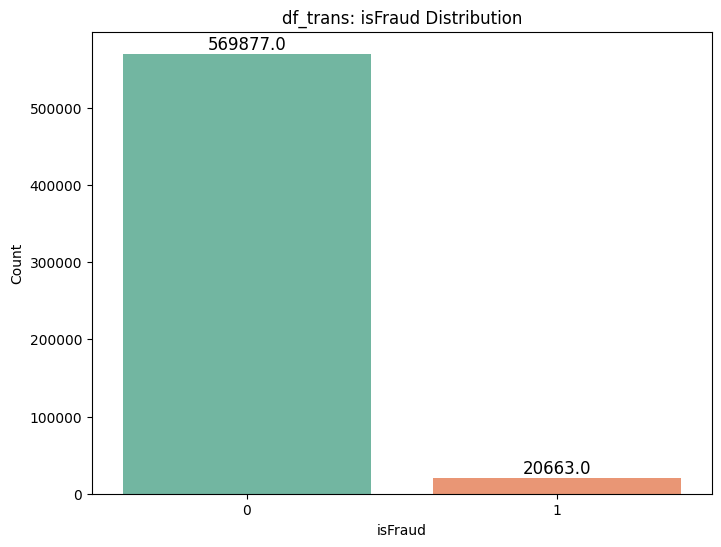

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.countplot(x='isFraud', data=df_trans, palette='Set2')

# Add counts on top of bars
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height()}',
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='bottom', fontsize=12)

plt.title('df_trans: isFraud Distribution')
plt.xlabel('isFraud')
plt.ylabel('Count')
plt.show()


Dataset relationship

In [89]:
common_ids = len(set(df_trans['TransactionID']) & set(df_id['TransactionID']))
print("Number of common TransactionIDs:", common_ids)

Number of common TransactionIDs: 144233


In [90]:
def categorize_skew_kurt(df):
    """
    Returns a DataFrame with skewness and kurtosis for all numerical columns.
    """
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    skewness = df[numeric_cols].skew()
    kurt = df[numeric_cols].kurt()  # Fisher kurtosis (normal=0)

    result = pd.DataFrame({
        "Column": numeric_cols,
        "Skewness": skewness,
        "Kurtosis": kurt,
        "StdDev": df[numeric_cols].std()
    }).reset_index(drop=True)

    # Skewness type
    def get_skew_type(val):
        if val < -2:
            return "Highly Left-Skewed"
        elif val < -1:
            return "Moderately Left-Skewed"
        elif val > 2:
            return "Highly Right-Skewed"
        elif val > 1:
            return "Moderately Right-Skewed"
        else:
            return "Approximately Symmetric"

    # Kurtosis type
    def get_kurt_type(val):
        if val > 1:
            return "Leptokurtic (Heavy tails)"
        elif val < -1:
            return "Platykurtic (Light tails)"
        else:
            return "Mesokurtic (Normal-like)"

    result["Skewness Type"] = result["Skewness"].apply(get_skew_type)
    result["Kurtosis Type"] = result["Kurtosis"].apply(get_kurt_type)

    # Flag constant features
    result.loc[result["StdDev"] == 0, ["Skewness Type", "Kurtosis Type"]] = "Constant Feature"

    return result.sort_values(by="Skewness", key=abs, ascending=False)


In [91]:
skew_kurt_trans = categorize_skew_kurt(df_trans)

In [92]:
display(skew_kurt_trans.head(15))

,Column,Skewness,Kurtosis,StdDev,Skewness Type,Kurtosis Type
11,dist2,inf,NaN,inf,Highly Right-Skewed,Mesokurtic (Normal-like)
39,D14,inf,NaN,136.375000,Highly Right-Skewed,Mesokurtic (Normal-like)
38,D13,inf,NaN,67.625000,Highly Right-Skewed,Mesokurtic (Normal-like)
37,D12,inf,NaN,124.312500,Highly Right-Skewed,Mesokurtic (Normal-like)
32,D7,inf,NaN,99.750000,Highly Right-Skewed,Mesokurtic (Normal-like)
359,V319,181.833649,47649.898438,332.304840,Highly Right-Skewed,Leptokurtic (Heavy tails)
175,V135,144.883194,31814.572266,293.847565,Highly Right-Skewed,Leptokurtic (Heavy tails)
361,V321,123.556473,27445.333984,382.053162,Highly Right-Skewed,Leptokurtic (Heavy tails)
254,V214,119.173615,18337.169922,571.834290,Highly Right-Skewed,Leptokurtic (Heavy tails)
316,V276,108.717972,15015.940430,615.659729,Highly Right-Skewed,Leptokurtic (Heavy tails)


In [93]:
skew_kurt_id = categorize_skew_kurt(df_id)
print("Skewness & Kurtosis: Identity Data")
display(skew_kurt_id.head(15))

Skewness & Kurtosis: Identity Data


,Column,Skewness,Kurtosis,StdDev,Skewness Type,Kurtosis Type
8,id_08,-inf,NaN,26.078125,Highly Left-Skewed,Mesokurtic (Normal-like)
7,id_07,-inf,NaN,11.382812,Highly Left-Skewed,Mesokurtic (Normal-like)
19,id_22,inf,NaN,6.898438,Highly Right-Skewed,Mesokurtic (Normal-like)
20,id_24,inf,NaN,2.371094,Highly Right-Skewed,Mesokurtic (Normal-like)
15,id_18,inf,NaN,1.561523,Highly Right-Skewed,Mesokurtic (Normal-like)
18,id_21,inf,NaN,198.750000,Highly Right-Skewed,Mesokurtic (Normal-like)
21,id_25,inf,NaN,97.437500,Highly Right-Skewed,Mesokurtic (Normal-like)
22,id_26,inf,NaN,32.093750,Highly Right-Skewed,Mesokurtic (Normal-like)
2,id_02,1.838789,4.014414,159651.812500,Moderately Right-Skewed,Leptokurtic (Heavy tails)
0,TransactionID,0.394459,-1.242738,178849.571186,Approximately Symmetric,Platykurtic (Light tails)


In [94]:
def CalcOutliers(df_num):

    # calculating mean and std of the array
    data_mean, data_std = np.mean(df_num), np.std(df_num)

    # seting the cut line to both higher and lower values
    # You can change this value
    cut = data_std * 3

    #Calculating the higher and lower cut values
    lower, upper = data_mean - cut, data_mean + cut

    # creating an array of lower, higher and total outlier values
    outliers_lower = [x for x in df_num if x < lower]
    outliers_higher = [x for x in df_num if x > upper]
    outliers_total = [x for x in df_num if x < lower or x > upper]

    # array without outlier values
    outliers_removed = [x for x in df_num if x > lower and x < upper]

    print('Identified lowest outliers: %d' % len(outliers_lower)) # printing total number of values in lower cut of outliers
    print('Identified upper outliers: %d' % len(outliers_higher)) # printing total number of values in higher cut of outliers
    print('Total outlier observations: %d' % len(outliers_total)) # printing total number of values outliers of both sides
    print('Non-outlier observations: %d' % len(outliers_removed)) # printing total number of non outlier values
    print("Total percentual of Outliers: ", round((len(outliers_total) / len(outliers_removed) )*100, 4)) # Percentual of outliers in points

    return

def resumetable(df):
    print(f"Dataset Shape: {df.shape}")
    summary = pd.DataFrame(df.dtypes,columns=['dtypes'])
    summary = summary.reset_index()
    summary['Name'] = summary['index']
    summary = summary[['Name','dtypes']]
    summary['Missing'] = df.isnull().sum().values
    summary['Uniques'] = df.nunique().values
    summary['First Value'] = df.loc[0].values
    summary['Second Value'] = df.loc[1].values
    summary['Third Value'] = df.loc[2].values

    for name in summary['Name'].value_counts().index:
        summary.loc[summary['Name'] == name, 'Entropy'] = round(stats.entropy(df[name].value_counts(normalize=True), base=2),2)

    return summary

In [95]:
df_trans['TransactionAmt'] = df_trans['TransactionAmt'].astype(float)
print("Transaction Amounts Quantiles:")
print(df_trans['TransactionAmt'].quantile([.01, .025, .1, .25, .5, .75, .9, .975, .99]))

Transaction Amounts Quantiles:
0.010       9.242188
0.025      14.500000
0.100      25.953125
0.250      43.312500
0.500      68.750000
0.750     125.000000
0.900     275.250000
0.975     648.262500
0.990    1104.000000
Name: TransactionAmt, dtype: float64


Plotting transaction amount values distribution

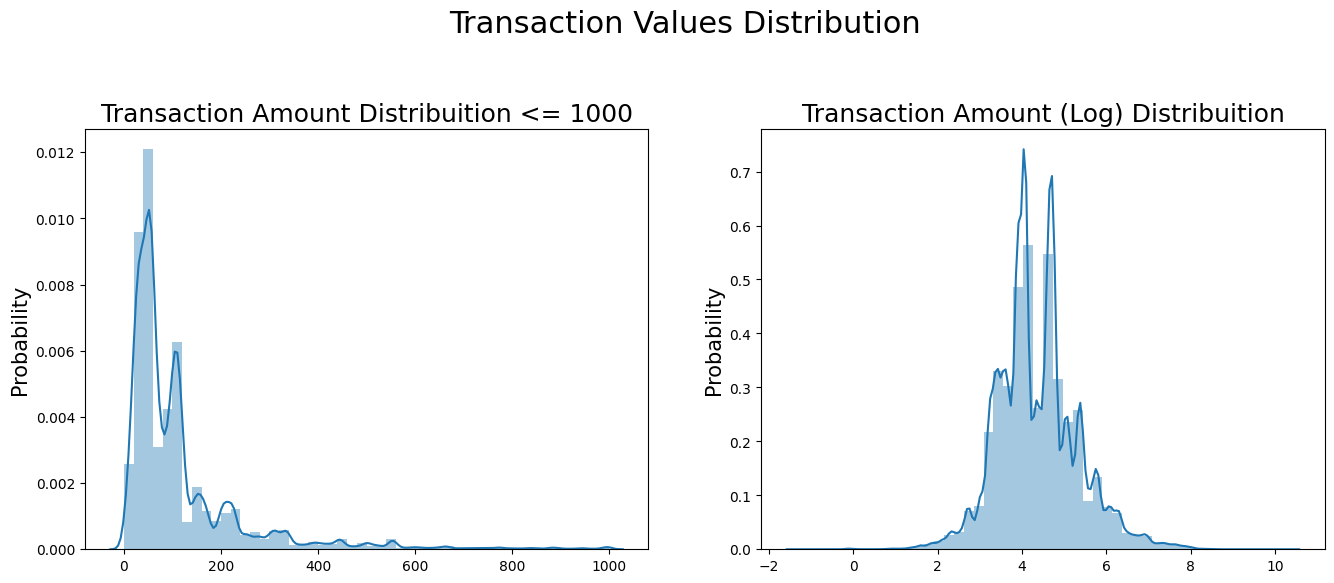

<Figure size 1600x1200 with 0 Axes>

In [96]:
plt.figure(figsize=(16,12))
plt.suptitle('Transaction Values Distribution', fontsize=22)
plt.subplot(221)
g = sns.distplot(df_trans[df_trans['TransactionAmt'] <= 1000]['TransactionAmt'])
g.set_title("Transaction Amount Distribuition <= 1000", fontsize=18)
g.set_xlabel("")
g.set_ylabel("Probability", fontsize=15)

plt.subplot(222)
g1 = sns.distplot(np.log(df_trans['TransactionAmt']))
g1.set_title("Transaction Amount (Log) Distribuition", fontsize=18)
g1.set_xlabel("")
g1.set_ylabel("Probability", fontsize=15)

plt.figure(figsize=(16,12))
plt.show()


In [97]:
CalcOutliers(df_trans['TransactionAmt'])

Identified lowest outliers: 0
Identified upper outliers: 10097
Total outlier observations: 10097
Non-outlier observations: 580443
Total percentual of Outliers:  1.7395


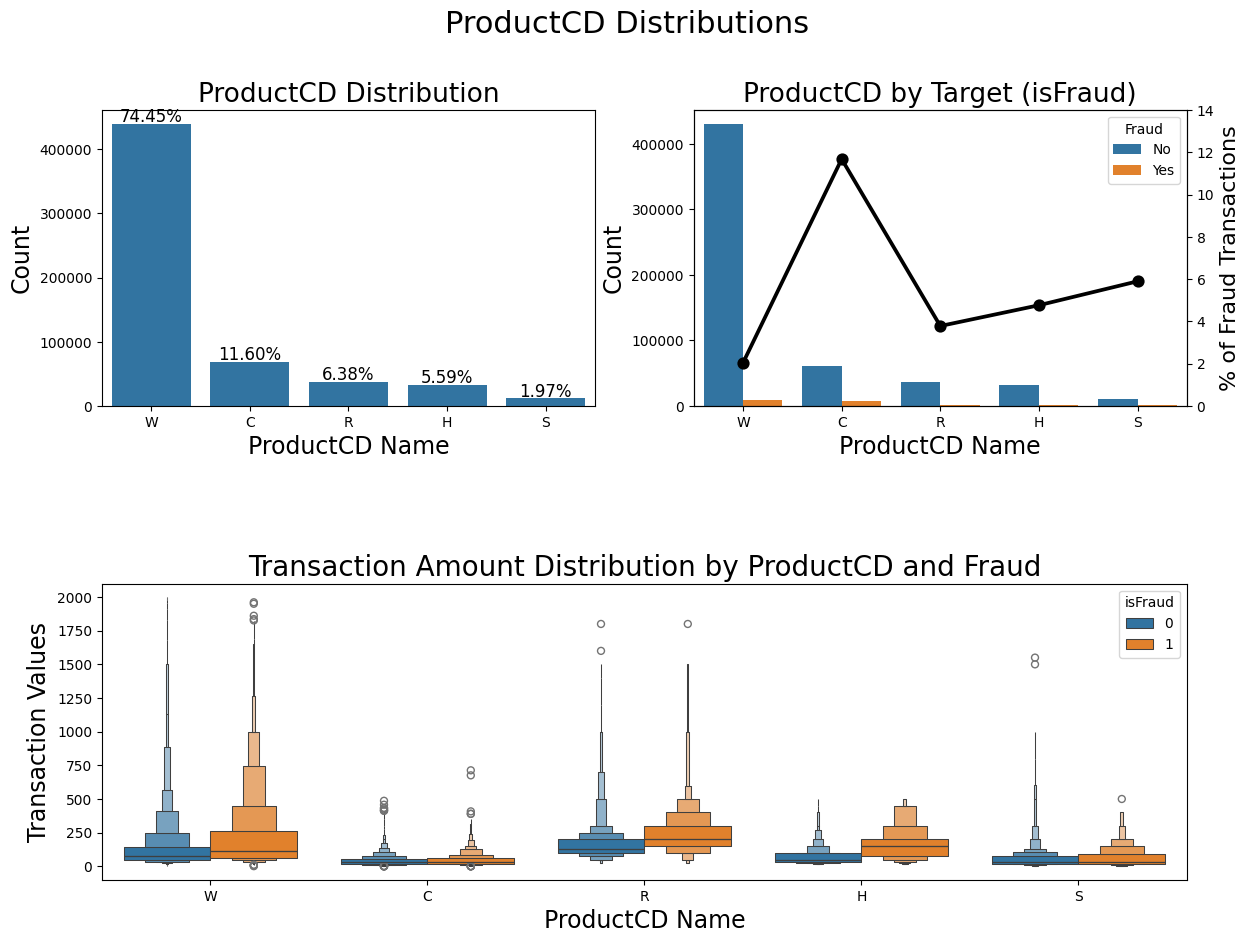

In [98]:
tmp = pd.crosstab(df_trans['ProductCD'], df_trans['isFraud'], normalize='index') * 100
tmp = tmp.reset_index()
tmp.rename(columns={0: 'NoFraud', 1: 'Fraud'}, inplace=True)

total = len(df_trans)  # used for percentage labels

plt.figure(figsize=(14, 10))
plt.suptitle('ProductCD Distributions', fontsize=22)

# ---------- (1) ProductCD overall distribution ----------
plt.subplot(221)
g = sns.countplot(x='ProductCD', data=df_trans, order=df_trans['ProductCD'].value_counts().index)

g.set_title("ProductCD Distribution", fontsize=19)
g.set_xlabel("ProductCD Name", fontsize=17)
g.set_ylabel("Count", fontsize=17)

for p in g.patches:
    height = p.get_height()
    g.text(p.get_x() + p.get_width()/2.,
           height + total*0.005,
           f'{height/total*100:.2f}%',
           ha="center", fontsize=12)

# ---------- (2) ProductCD by Fraud + Fraud Rate Line ----------
plt.subplot(222)
g1 = sns.countplot(x='ProductCD', hue='isFraud', data=df_trans,
                   order=df_trans['ProductCD'].value_counts().index)

g1.set_title("ProductCD by Target (isFraud)", fontsize=19)
g1.set_xlabel("ProductCD Name", fontsize=17)
g1.set_ylabel("Count", fontsize=17)
plt.legend(title='Fraud', labels=['No', 'Yes'])

# Fraud rate line (secondary axis)
gt = g1.twinx()
sns.pointplot(x='ProductCD', y='Fraud', data=tmp,
              order=df_trans['ProductCD'].value_counts().index,
              color='black')
gt.set_ylabel("% of Fraud Transactions", fontsize=16)
gt.set_ylim(0, tmp['Fraud'].max() * 1.2)

# ---------- (3) Transaction Amount Distribution ----------
plt.subplot(212)
g3 = sns.boxenplot(x='ProductCD', y='TransactionAmt', hue='isFraud',
                   data=df_trans[df_trans['TransactionAmt'] <= 2000],
                   order=df_trans['ProductCD'].value_counts().index)

g3.set_title("Transaction Amount Distribution by ProductCD and Fraud", fontsize=20)
g3.set_xlabel("ProductCD Name", fontsize=17)
g3.set_ylabel("Transaction Values", fontsize=17)

plt.subplots_adjust(hspace=0.6, top=0.88)
plt.show()

In [99]:
from scipy import stats
resumetable(df_trans[['card1', 'card2', 'card3','card4', 'card5', 'card6']])

Dataset Shape: (590540, 6)


,Name,dtypes,Missing,Uniques,First Value,Second Value,Third Value,Entropy
0,card1,int16,0,13553,13926,2755,4663,9.97
1,card2,float16,8933,500,NaN,404.0,490.0,6.32
2,card3,float16,1565,114,150.0,150.0,150.0,0.68
3,card4,object,1577,4,discover,mastercard,visa,1.09
4,card5,float16,4259,119,142.0,102.0,166.0,2.66
5,card6,object,1571,4,credit,credit,debit,0.82


In [100]:
print("Card Features Quantiles: ")
print(df_trans[['card1', 'card2', 'card3', 'card5']].quantile([0.01, .025, .1, .25, .5, .75, .975, .99]))

Card Features Quantiles: 
         card1  card2  card3  card5
0.010   1338.0  100.0  144.0  102.0
0.025   1675.0  111.0  150.0  102.0
0.100   2803.0  111.0  150.0  126.0
0.250   6019.0  214.0  150.0  166.0
0.500   9678.0  361.0  150.0  226.0
0.750  14184.0  512.0  150.0  226.0
0.975  18018.0  583.0  185.0  226.0
0.990  18238.0  583.0  185.0  226.0


In [101]:
df_trans.loc[df_trans.card3.isin(df_trans.card3.value_counts()[df_trans.card3.value_counts() < 200].index), 'card3'] = "Others"
df_trans.loc[df_trans.card5.isin(df_trans.card5.value_counts()[df_trans.card5.value_counts() < 300].index), 'card5'] = "Others"

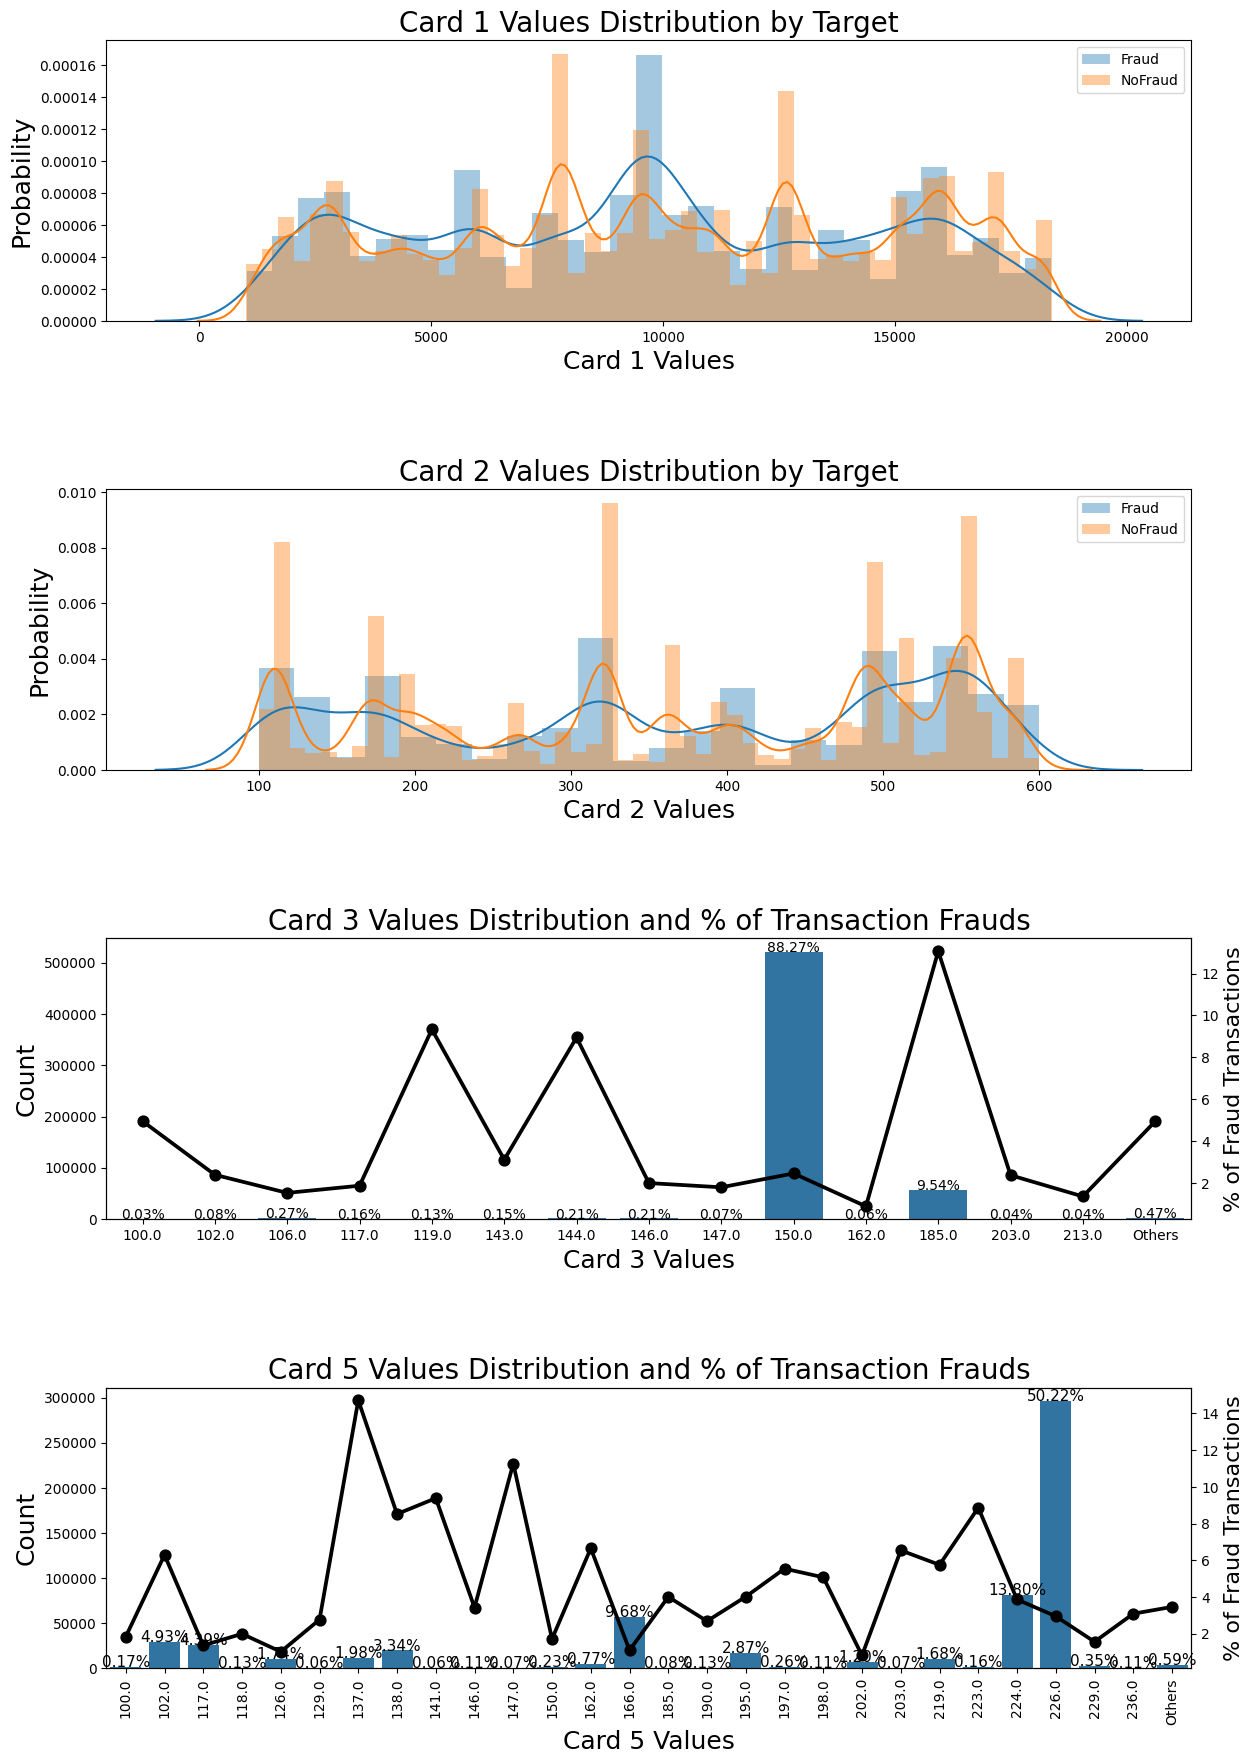

In [102]:
tmp = pd.crosstab(df_trans['card3'], df_trans['isFraud'], normalize='index') * 100
tmp = tmp.reset_index()
tmp.rename(columns={0:'NoFraud', 1:'Fraud'}, inplace=True)

tmp2 = pd.crosstab(df_trans['card5'], df_trans['isFraud'], normalize='index') * 100
tmp2 = tmp2.reset_index()
tmp2.rename(columns={0:'NoFraud', 1:'Fraud'}, inplace=True)

plt.figure(figsize=(14,22))

plt.subplot(411)
g = sns.distplot(df_trans[df_trans['isFraud'] == 1]['card1'], label='Fraud')
g = sns.distplot(df_trans[df_trans['isFraud'] == 0]['card1'], label='NoFraud')
g.legend()
g.set_title("Card 1 Values Distribution by Target", fontsize=20)
g.set_xlabel("Card 1 Values", fontsize=18)
g.set_ylabel("Probability", fontsize=18)

plt.subplot(412)
g1 = sns.distplot(df_trans[df_trans['isFraud'] == 1]['card2'].dropna(), label='Fraud')
g1 = sns.distplot(df_trans[df_trans['isFraud'] == 0]['card2'].dropna(), label='NoFraud')
g1.legend()
g1.set_title("Card 2 Values Distribution by Target", fontsize=20)
g1.set_xlabel("Card 2 Values", fontsize=18)
g1.set_ylabel("Probability", fontsize=18)

plt.subplot(413)
g2 = sns.countplot(x='card3', data=df_trans, order=list(tmp.card3.values))
g22 = g2.twinx()
gg2 = sns.pointplot(x='card3', y='Fraud', data=tmp,
                    color='black', order=list(tmp.card3.values))
gg2.set_ylabel("% of Fraud Transactions", fontsize=16)
g2.set_title("Card 3 Values Distribution and % of Transaction Frauds", fontsize=20)
g2.set_xlabel("Card 3 Values", fontsize=18)
g2.set_ylabel("Count", fontsize=18)
for p in g2.patches:
    height = p.get_height()
    g2.text(p.get_x()+p.get_width()/2.,
            height + 25,
            '{:1.2f}%'.format(height/total*100),
            ha="center")

plt.subplot(414)
g3 = sns.countplot(x='card5', data=df_trans, order=list(tmp2.card5.values))
g3t = g3.twinx()
g3t = sns.pointplot(x='card5', y='Fraud', data=tmp2,
                    color='black', order=list(tmp2.card5.values))
g3t.set_ylabel("% of Fraud Transactions", fontsize=16)
g3.set_title("Card 5 Values Distribution and % of Transaction Frauds", fontsize=20)
g3.set_xticklabels(g3.get_xticklabels(),rotation=90)
g3.set_xlabel("Card 5 Values", fontsize=18)
g3.set_ylabel("Count", fontsize=18)
for p in g3.patches:
    height = p.get_height()
    g3.text(p.get_x()+p.get_width()/2.,
            height + 3,
            '{:1.2f}%'.format(height/total*100),
            ha="center",fontsize=11)

plt.subplots_adjust(hspace = 0.6, top = 0.85)


plt.show()

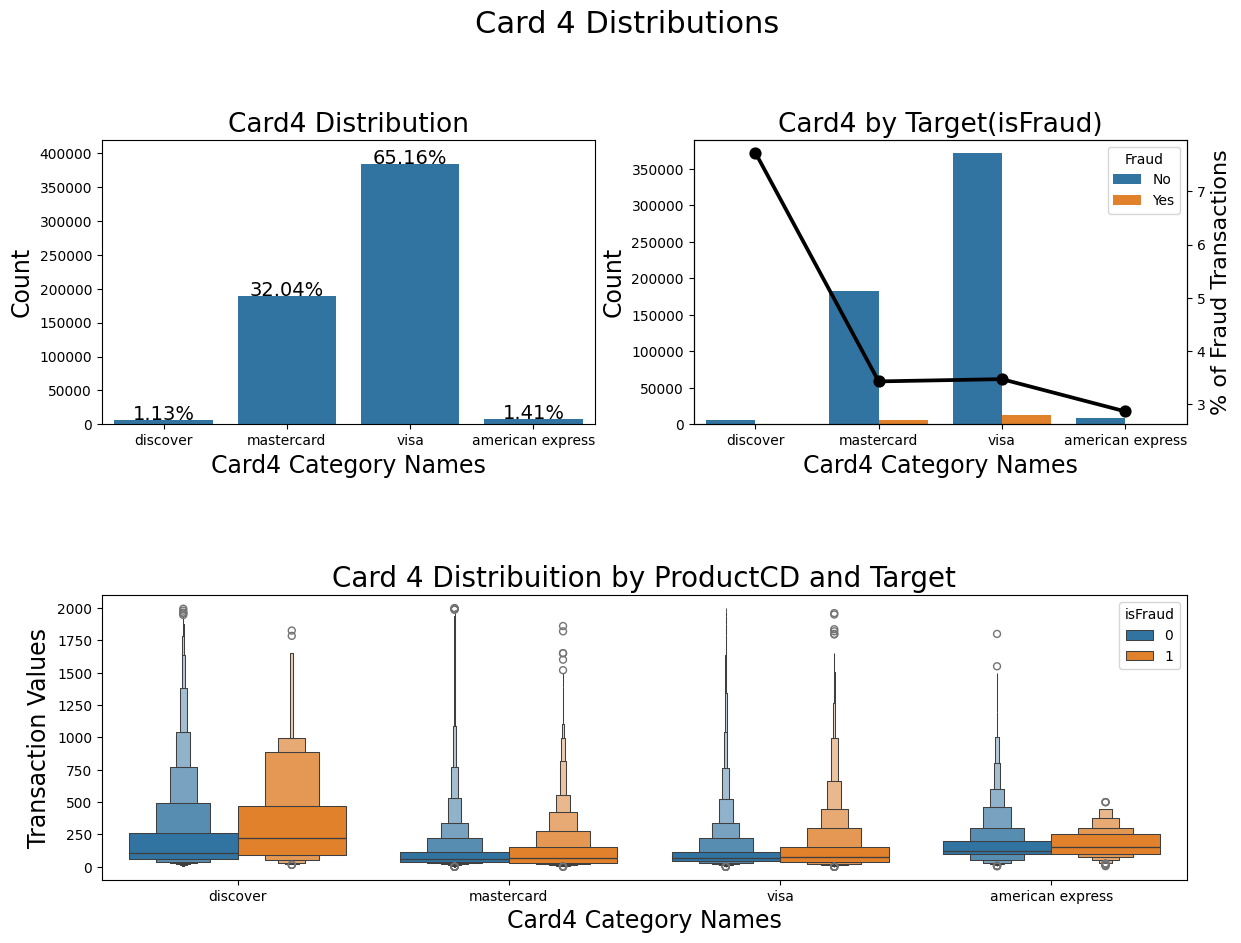

In [103]:
# Categorical
tmp = pd.crosstab(df_trans['card4'], df_trans['isFraud'], normalize='index') * 100
tmp = tmp.reset_index()
tmp.rename(columns={0:'NoFraud', 1:'Fraud'}, inplace=True)

plt.figure(figsize=(14,10))
plt.suptitle('Card 4 Distributions', fontsize=22)

plt.subplot(221)
g = sns.countplot(x='card4', data=df_trans)
# plt.legend(title='Fraud', loc='upper center', labels=['No', 'Yes'])
g.set_title("Card4 Distribution", fontsize=19)
g.set_ylim(0,420000)
g.set_xlabel("Card4 Category Names", fontsize=17)
g.set_ylabel("Count", fontsize=17)
for p in g.patches:
    height = p.get_height()
    g.text(p.get_x()+p.get_width()/2.,
            height + 3,
            '{:1.2f}%'.format(height/total*100),
            ha="center",fontsize=14)


plt.subplot(222)
g1 = sns.countplot(x='card4', hue='isFraud', data=df_trans)
plt.legend(title='Fraud', loc='best', labels=['No', 'Yes'])
gt = g1.twinx()
gt = sns.pointplot(x='card4', y='Fraud', data=tmp,
                   color='black',
                   order=['discover', 'mastercard', 'visa', 'american express'])
gt.set_ylabel("% of Fraud Transactions", fontsize=16)
g1.set_title("Card4 by Target(isFraud)", fontsize=19)
g1.set_xlabel("Card4 Category Names", fontsize=17)
g1.set_ylabel("Count", fontsize=17)

plt.subplot(212)
g3 = sns.boxenplot(x='card4', y='TransactionAmt', hue='isFraud',
              data=df_trans[df_trans['TransactionAmt'] <= 2000] )
g3.set_title("Card 4 Distribuition by ProductCD and Target", fontsize=20)
g3.set_xlabel("Card4 Category Names", fontsize=17)
g3.set_ylabel("Transaction Values", fontsize=17)

plt.subplots_adjust(hspace = 0.6, top = 0.85)

plt.show()

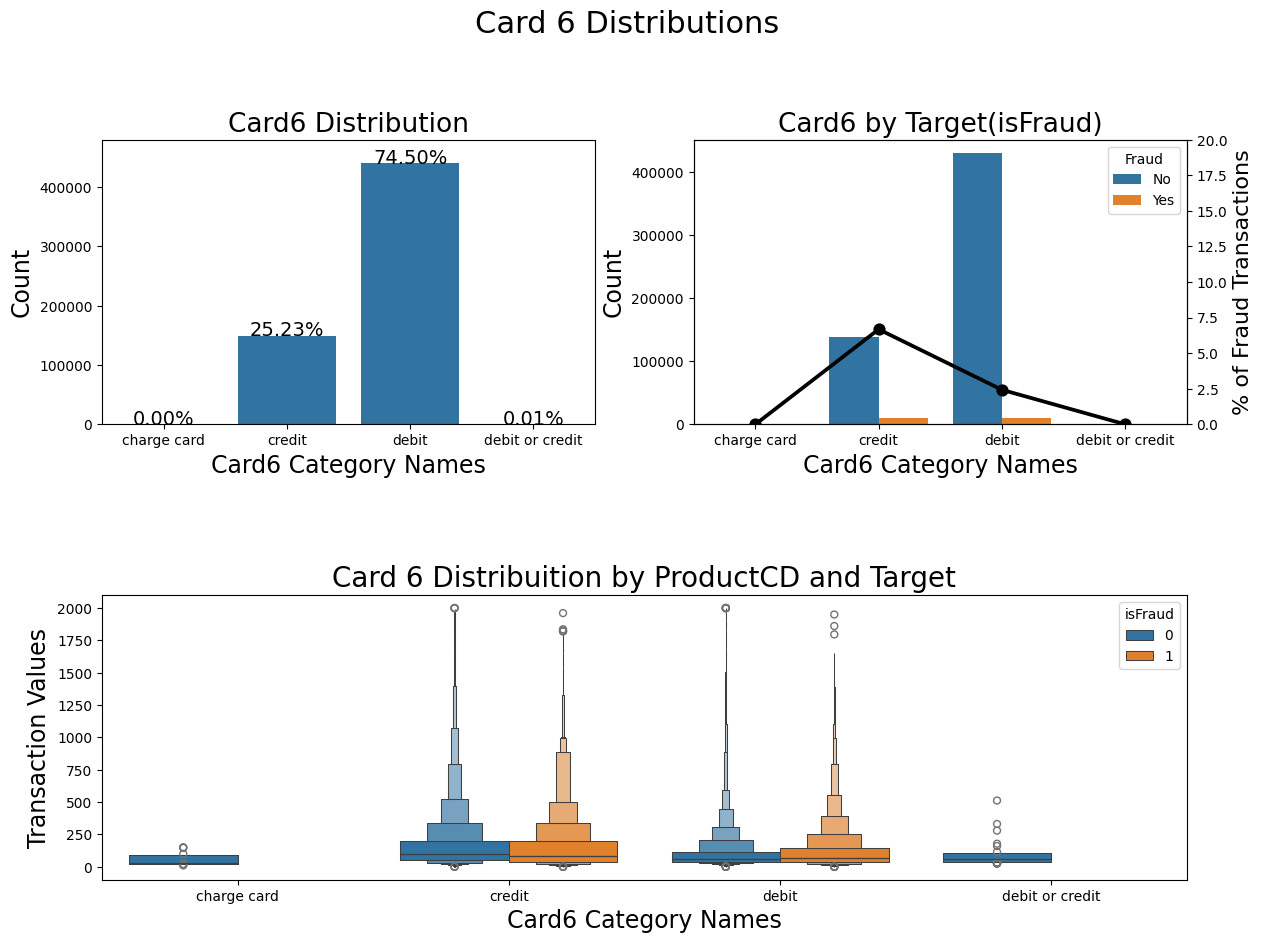

In [104]:
tmp = pd.crosstab(df_trans['card6'], df_trans['isFraud'], normalize='index') * 100
tmp = tmp.reset_index()
tmp.rename(columns={0:'NoFraud', 1:'Fraud'}, inplace=True)

plt.figure(figsize=(14,10))
plt.suptitle('Card 6 Distributions', fontsize=22)

plt.subplot(221)
g = sns.countplot(x='card6', data=df_trans, order=list(tmp.card6.values))
# plt.legend(title='Fraud', loc='upper center', labels=['No', 'Yes'])
g.set_title("Card6 Distribution", fontsize=19)
g.set_ylim(0,480000)
g.set_xlabel("Card6 Category Names", fontsize=17)
g.set_ylabel("Count", fontsize=17)
for p in g.patches:
    height = p.get_height()
    g.text(p.get_x()+p.get_width()/2.,
            height + 3,
            '{:1.2f}%'.format(height/total*100),
            ha="center",fontsize=14)

plt.subplot(222)
g1 = sns.countplot(x='card6', hue='isFraud', data=df_trans, order=list(tmp.card6.values))
plt.legend(title='Fraud', loc='best', labels=['No', 'Yes'])
gt = g1.twinx()
gt = sns.pointplot(x='card6', y='Fraud', data=tmp, order=list(tmp.card6.values),
                   color='black')
gt.set_ylim(0,20)
gt.set_ylabel("% of Fraud Transactions", fontsize=16)
g1.set_title("Card6 by Target(isFraud)", fontsize=19)
g1.set_xlabel("Card6 Category Names", fontsize=17)
g1.set_ylabel("Count", fontsize=17)

plt.subplot(212)
g3 = sns.boxenplot(x='card6', y='TransactionAmt', hue='isFraud', order=list(tmp.card6.values),
              data=df_trans[df_trans['TransactionAmt'] <= 2000] )
g3.set_title("Card 6 Distribuition by ProductCD and Target", fontsize=20)
g3.set_xlabel("Card6 Category Names", fontsize=17)
g3.set_ylabel("Transaction Values", fontsize=17)

plt.subplots_adjust(hspace = 0.6, top = 0.85)

plt.show()

Exploring M1-Mp features


In [105]:
# Fill missing M values
for col in ['M1','M2','M3','M4','M5','M6','M7','M8','M9']:
    df_trans[col] = df_trans[col].fillna("Miss")

def ploting_dist_ratio(df, col, lim=2000):

    total = len(df)
    total_amt = df['TransactionAmt'].sum()

    tmp = pd.crosstab(df[col], df['isFraud'], normalize='index') * 100
    tmp = tmp.reset_index()
    tmp.rename(columns={0:'NoFraud', 1:'Fraud'}, inplace=True)

    order = list(tmp[col].values)

    plt.figure(figsize=(20,5))
    plt.suptitle(f'{col} Distributions', fontsize=22)

    # ---------------- Count + Fraud Rate ----------------
    plt.subplot(121)
    g = sns.countplot(x=col, data=df, order=order)
    g.set_title(f"{col} Distribution\nCount and % Fraud", fontsize=18)
    g.set_xlabel(f"{col} Category Names", fontsize=16)
    g.set_ylabel("Count", fontsize=17)

    # Fraud rate line
    gt = g.twinx()
    sns.pointplot(x=col, y='Fraud', data=tmp, order=order, color='black')
    gt.set_ylabel("% of Fraud Transactions", fontsize=16)
    gt.set_ylim(0, tmp['Fraud'].max()*1.2)

    # Count % labels
    for p in g.patches:
        height = p.get_height()
        g.text(p.get_x()+p.get_width()/2.,
               height + total*0.002,
               f'{height/total*100:.2f}%',
               ha="center", fontsize=11)

    # ---------------- Amount Distribution + Fraud Amount Share ----------------
    perc_amt = (
        df.groupby(['isFraud', col])['TransactionAmt'].sum()
        .div(total_amt)
        .mul(100)
        .unstack('isFraud')
        .reset_index()
        .rename(columns={0:'NoFraud', 1:'Fraud'})
    )

    plt.subplot(122)
    g1 = sns.boxplot(x=col, y='TransactionAmt', hue='isFraud',
                     data=df[df['TransactionAmt'] <= lim],
                     order=order)

    g1.set_title(f"{col} Transaction Amount Distribution", fontsize=18)
    g1.set_xlabel(f"{col} Category Names", fontsize=16)
    g1.set_ylabel("Transaction Amount ($)", fontsize=16)

    # Fraud amount % line
    g1t = g1.twinx()
    sns.pointplot(x=col, y='Fraud', data=perc_amt, order=order, color='black')
    g1t.set_ylabel("% of Total Fraud Amount", fontsize=16)
    g1t.set_ylim(0, perc_amt['Fraud'].max()*1.2)

    plt.subplots_adjust(hspace=.4, wspace=0.35, top=0.80)
    plt.show()

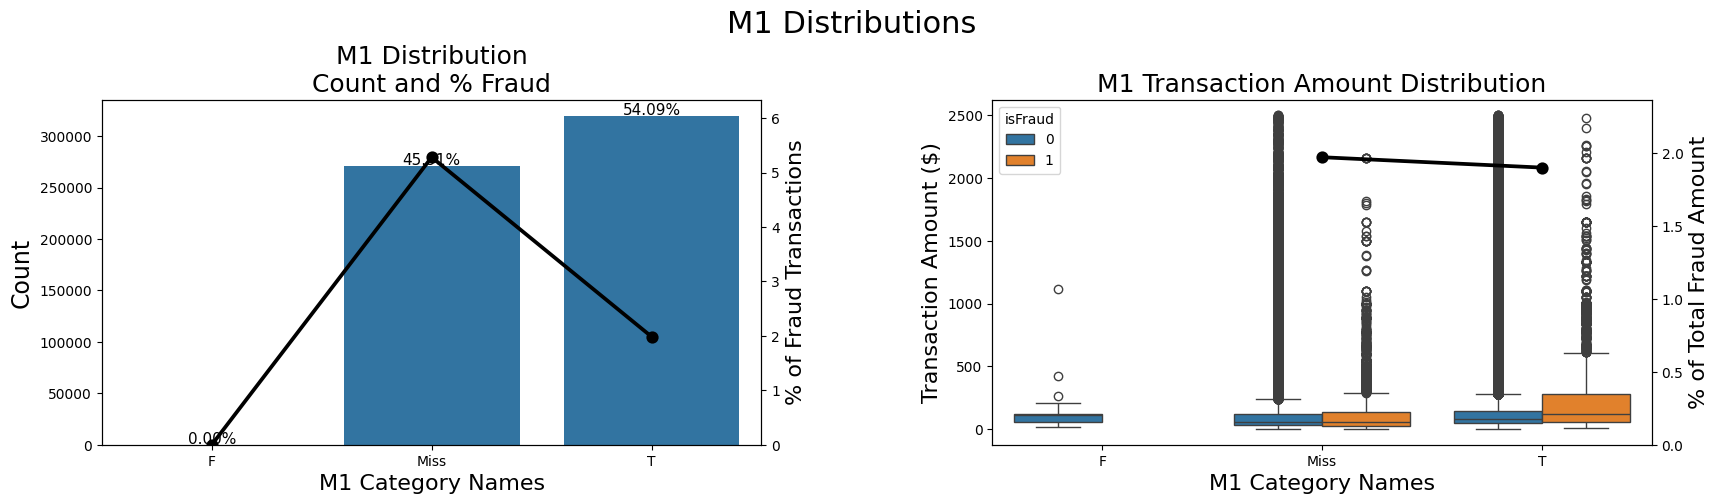

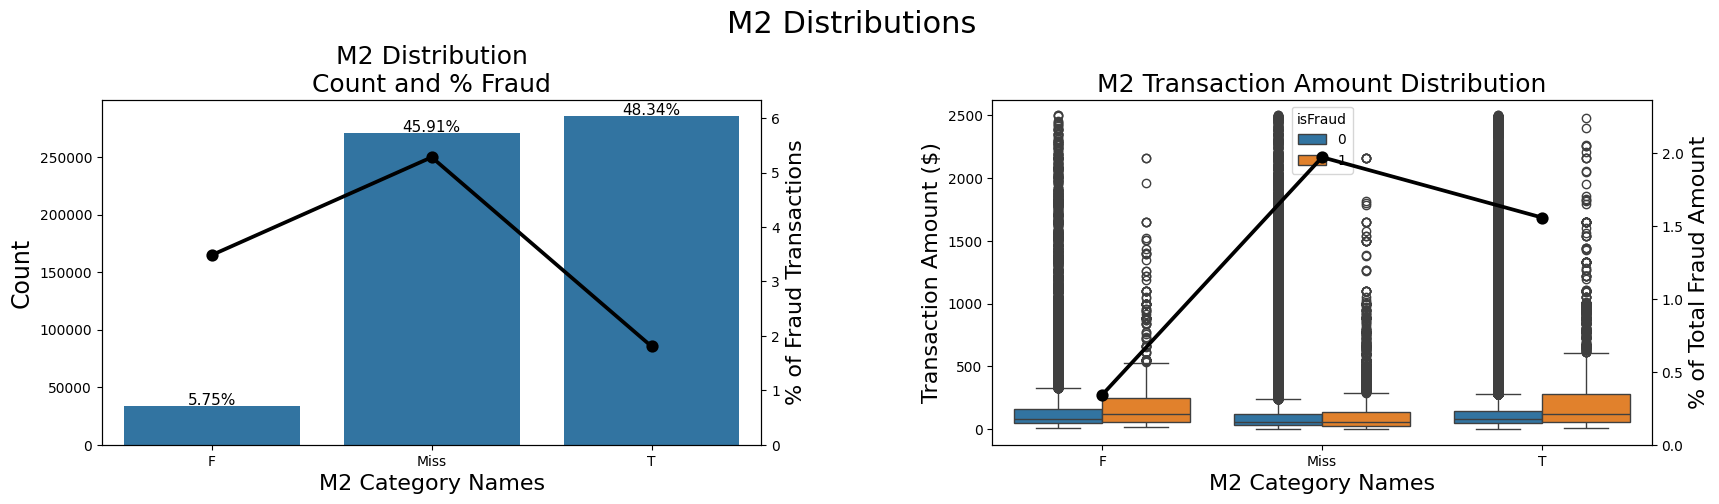

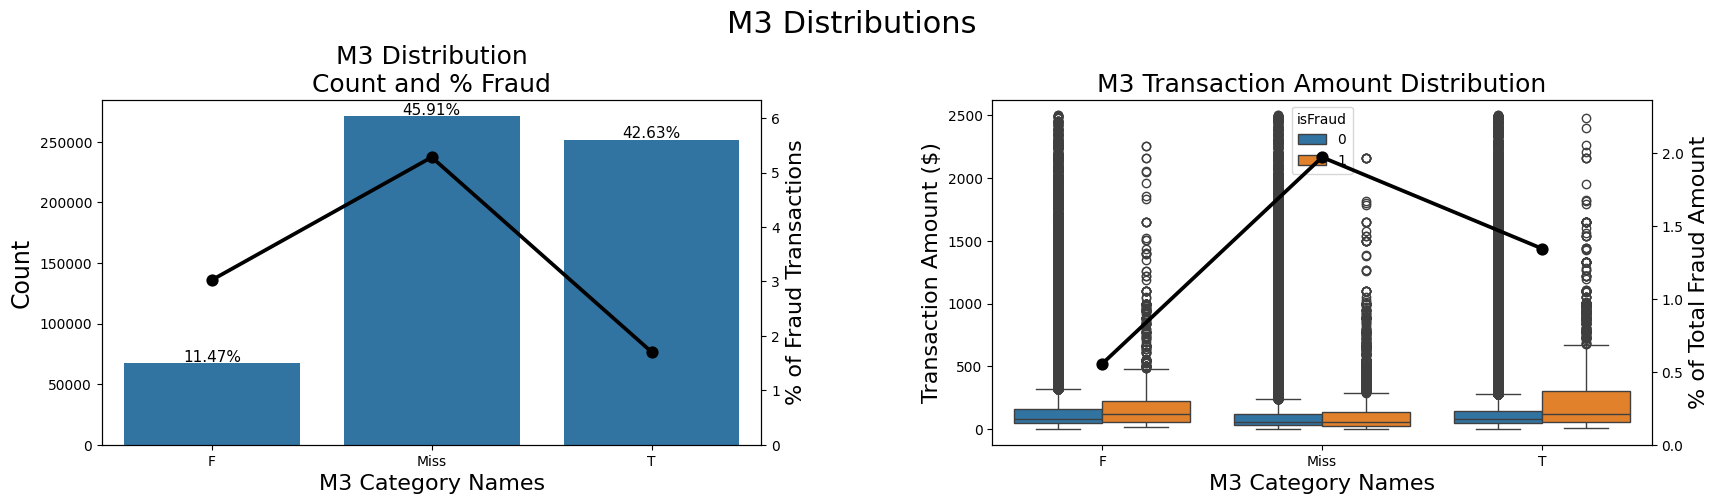

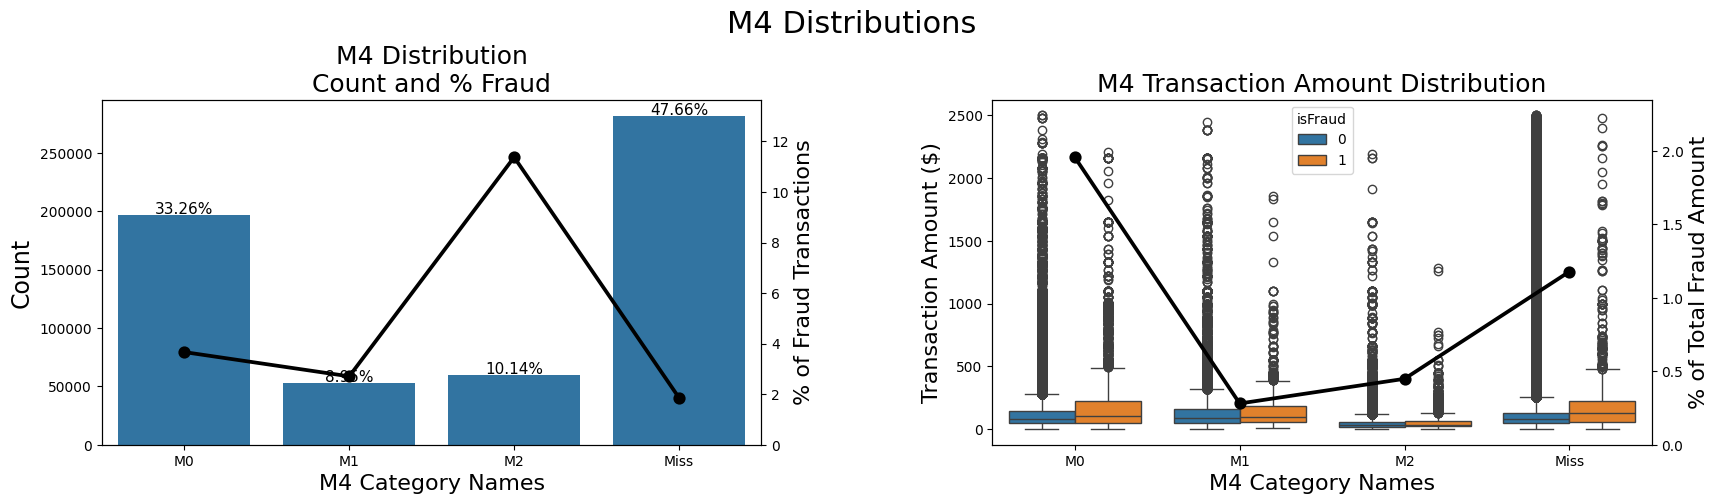

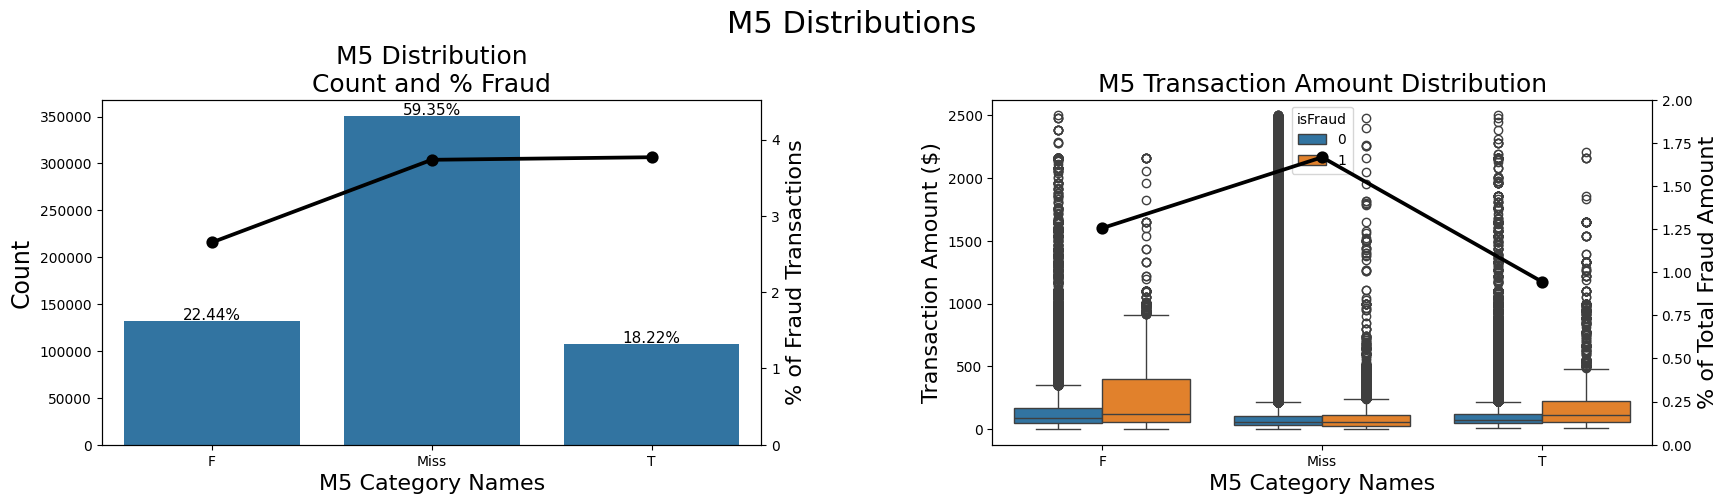

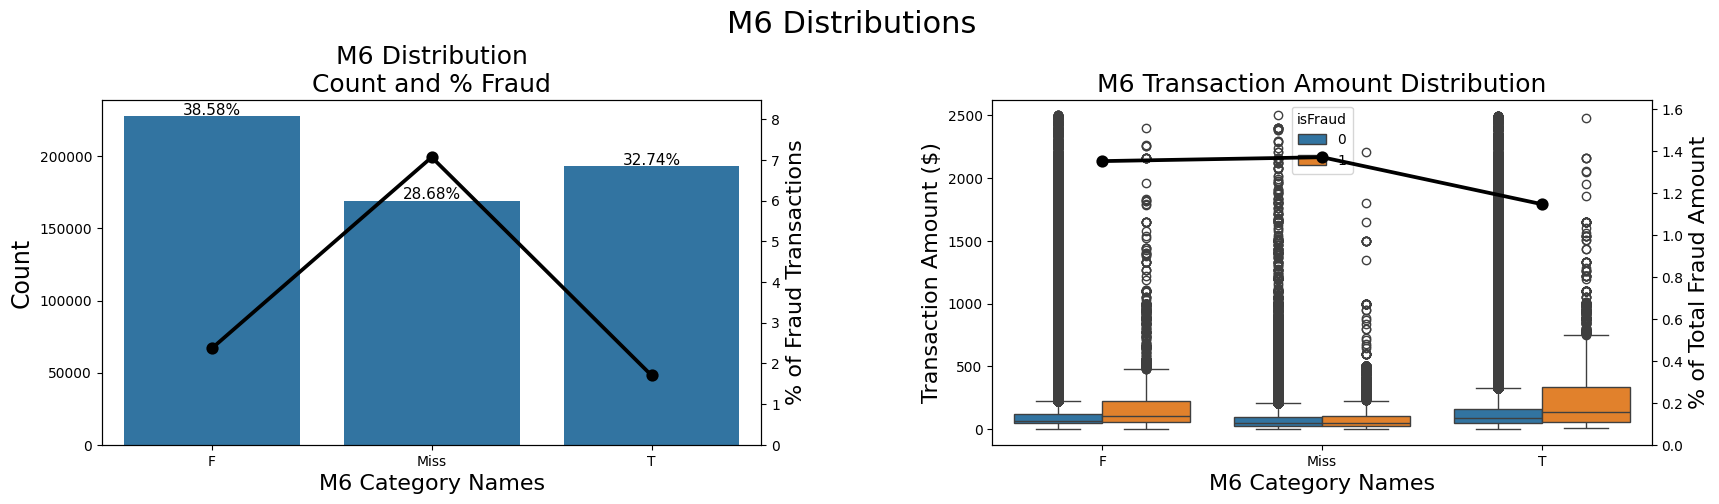

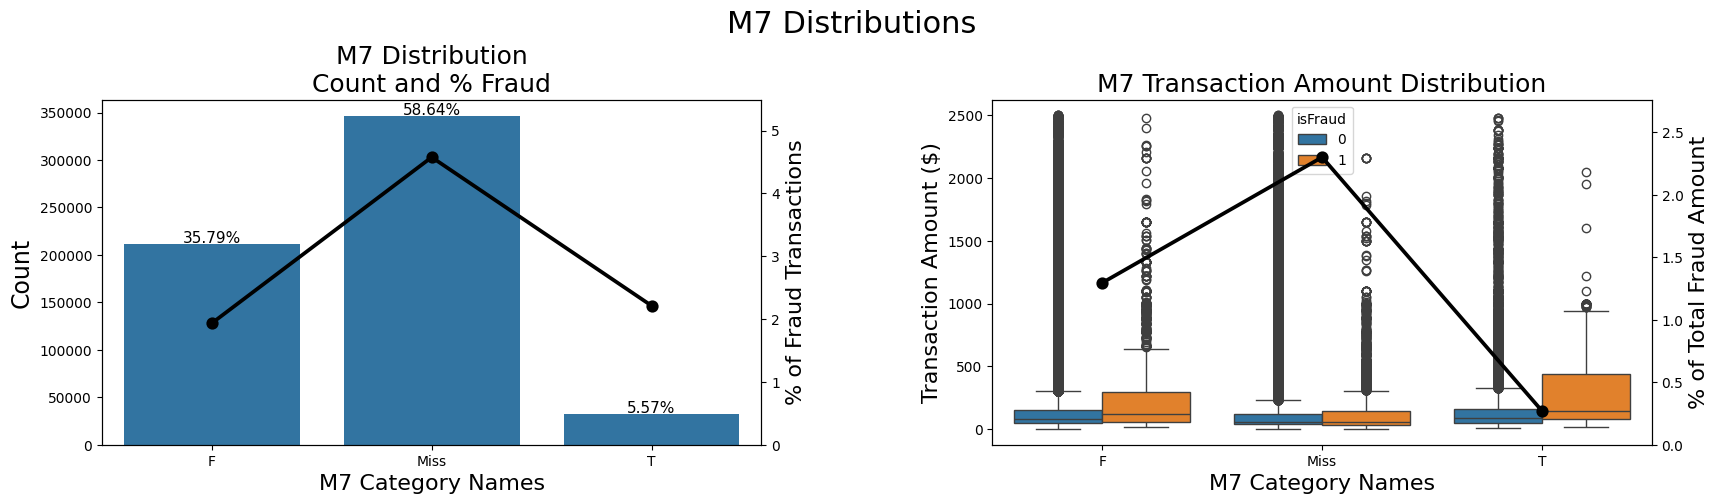

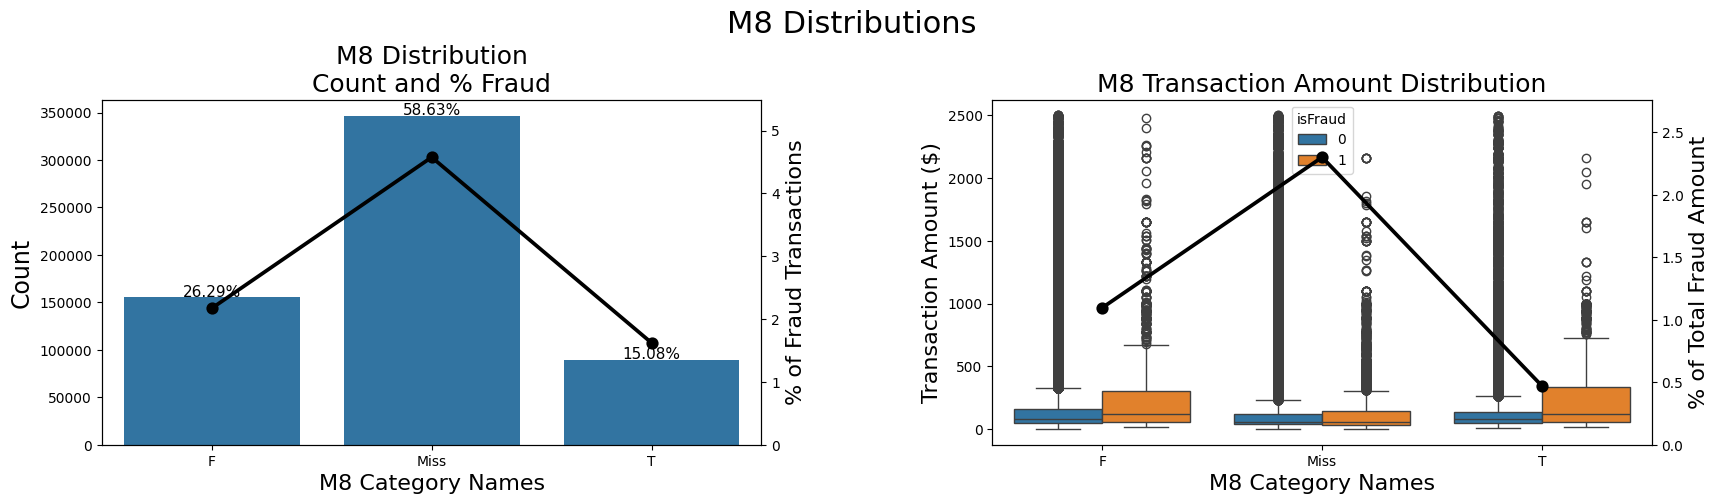

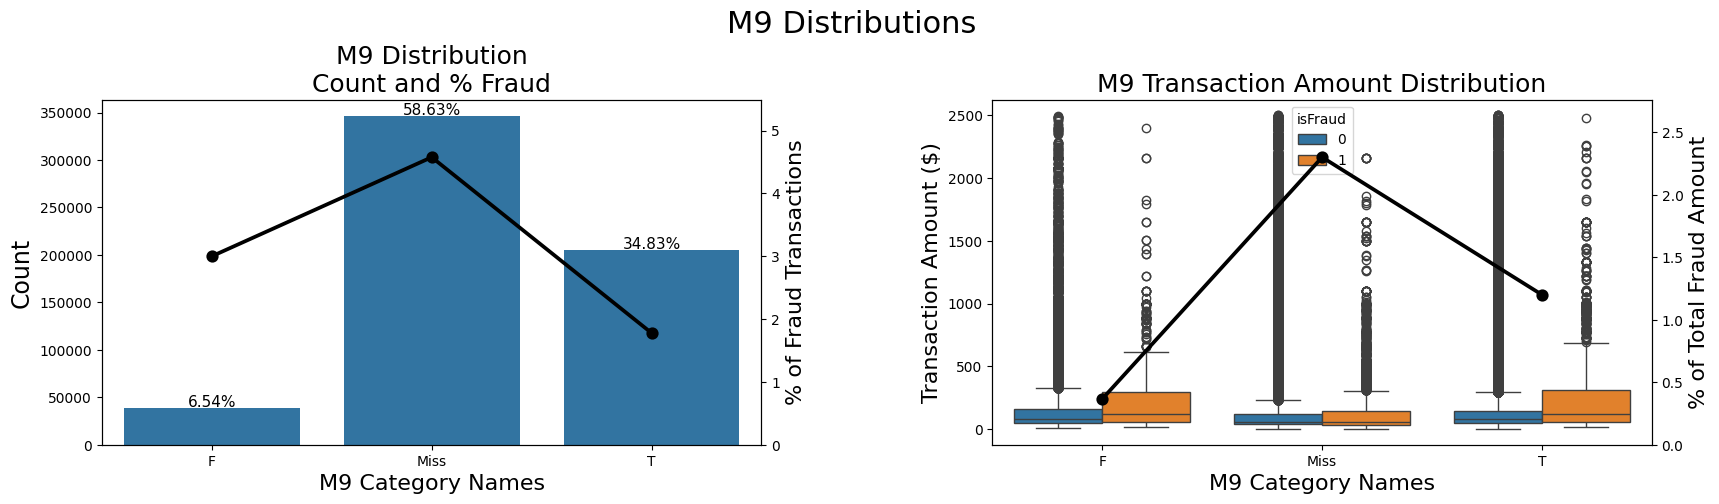

In [106]:
for col in ['M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']:
    ploting_dist_ratio(df_trans, col, lim=2500)


Addr1 and Addr2

In [107]:
print("Card Features Quantiles: ")
print(df_trans[['addr1', 'addr2']].quantile([0.01, .025, .1, .25, .5, .75, .90,.975, .99]))

Card Features Quantiles: 
       addr1  addr2
0.010  123.0   87.0
0.025  123.0   87.0
0.100  177.0   87.0
0.250  204.0   87.0
0.500  299.0   87.0
0.750  330.0   87.0
0.900  441.0   87.0
0.975  498.0   87.0
0.990  512.0   87.0


In [108]:
df_trans.loc[df_trans.addr1.isin(df_trans.addr1.value_counts()[df_trans.addr1.value_counts() <= 5000 ].index), 'addr1'] = "Others"
df_trans.loc[df_trans.addr2.isin(df_trans.addr2.value_counts()[df_trans.addr2.value_counts() <= 50 ].index), 'addr2'] = "Others"

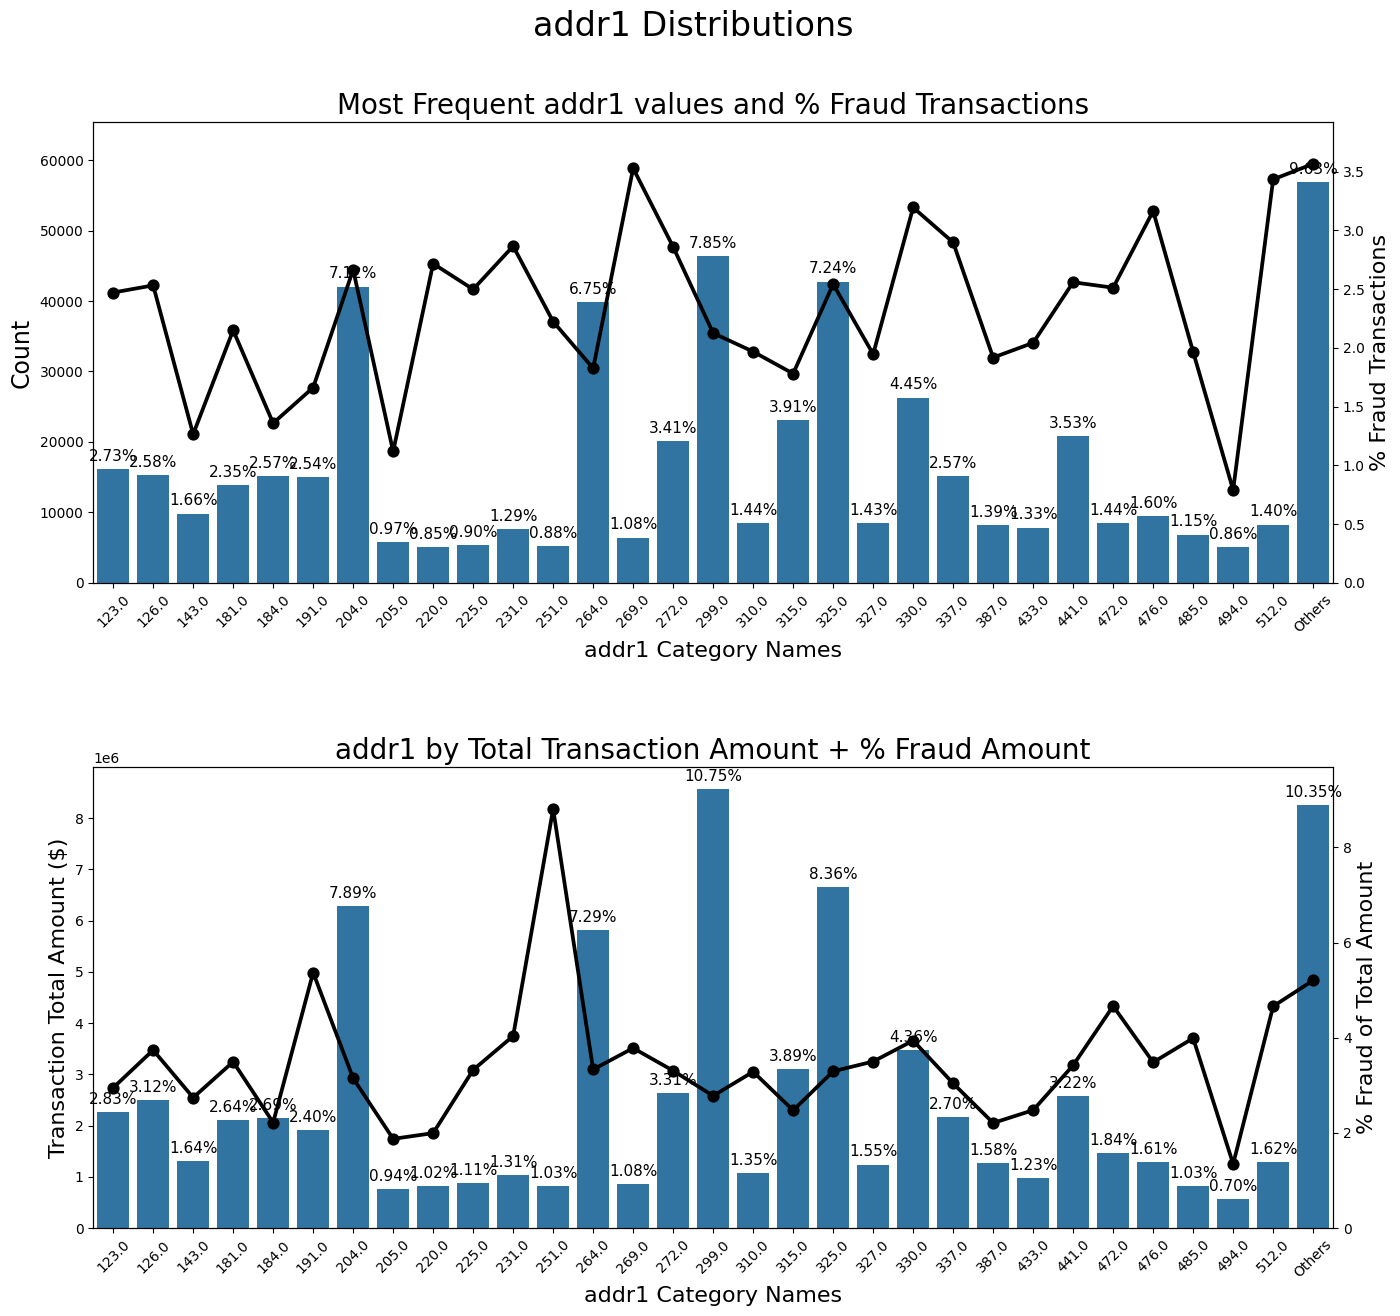

In [109]:
def ploting_cnt_amt(df, col, lim=2000):
    if df[col].dtype == 'float16':
        df[col] = df[col].astype('float32')

    total = len(df)
    total_amt = df['TransactionAmt'].sum()

    tmp = pd.crosstab(df[col], df['isFraud'], normalize='index') * 100
    tmp = tmp.reset_index()
    tmp.rename(columns={0:'NoFraud', 1:'Fraud'}, inplace=True)

    order = list(tmp[col].values)

    plt.figure(figsize=(16,14))
    plt.suptitle(f'{col} Distributions', fontsize=24)

    # ---------------- Count + Fraud Rate ----------------
    plt.subplot(211)
    g = sns.countplot(x=col, data=df, order=order)
    gt = g.twinx()
    sns.pointplot(x=col, y='Fraud', data=tmp, order=order, color='black')

    gt.set_ylim(0, tmp['Fraud'].max()*1.1)
    gt.set_ylabel("% Fraud Transactions", fontsize=16)
    g.set_title(f"Most Frequent {col} values and % Fraud Transactions", fontsize=20)
    g.set_xlabel(f"{col} Category Names", fontsize=16)
    g.set_ylabel("Count", fontsize=17)
    g.tick_params(axis='x', rotation=45)

    sizes = []
    for p in g.patches:
        height = p.get_height()
        sizes.append(height)
        g.text(p.get_x()+p.get_width()/2.,
               height + total*0.002,
               f'{height/total*100:.2f}%',
               ha="center", fontsize=11)

    g.set_ylim(0, max(sizes)*1.15)

    # ---------------- Total Amount + Fraud Amount % ----------------
    perc_amt = (
        df.groupby(['isFraud', col])['TransactionAmt'].sum()
        / df.groupby(col)['TransactionAmt'].sum() * 100
    ).unstack('isFraud').reset_index().fillna(0)

    perc_amt.rename(columns={0:'NoFraud', 1:'Fraud'}, inplace=True)
    amt = df.groupby(col)['TransactionAmt'].sum().reset_index()

    plt.subplot(212)
    g1 = sns.barplot(x=col, y='TransactionAmt', data=amt, order=order)
    g1t = g1.twinx()
    sns.pointplot(x=col, y='Fraud', data=perc_amt, order=order, color='black')

    g1t.set_ylim(0, perc_amt['Fraud'].max()*1.1)
    g1t.set_ylabel("% Fraud of Total Amount", fontsize=16)

    g1.set_title(f"{col} by Total Transaction Amount + % Fraud Amount", fontsize=20)
    g1.set_xlabel(f"{col} Category Names", fontsize=16)
    g1.set_ylabel("Transaction Total Amount ($)", fontsize=16)
    g1.tick_params(axis='x', rotation=45)

    for p in g1.patches:
        height = p.get_height()
        g1.text(p.get_x()+p.get_width()/2.,
                height + total_amt*0.002,
                f'{height/total_amt*100:.2f}%',
                ha="center", fontsize=11)

    plt.subplots_adjust(hspace=.4, top=0.9)
    plt.show()


# Run
ploting_cnt_amt(df_trans, 'addr1')


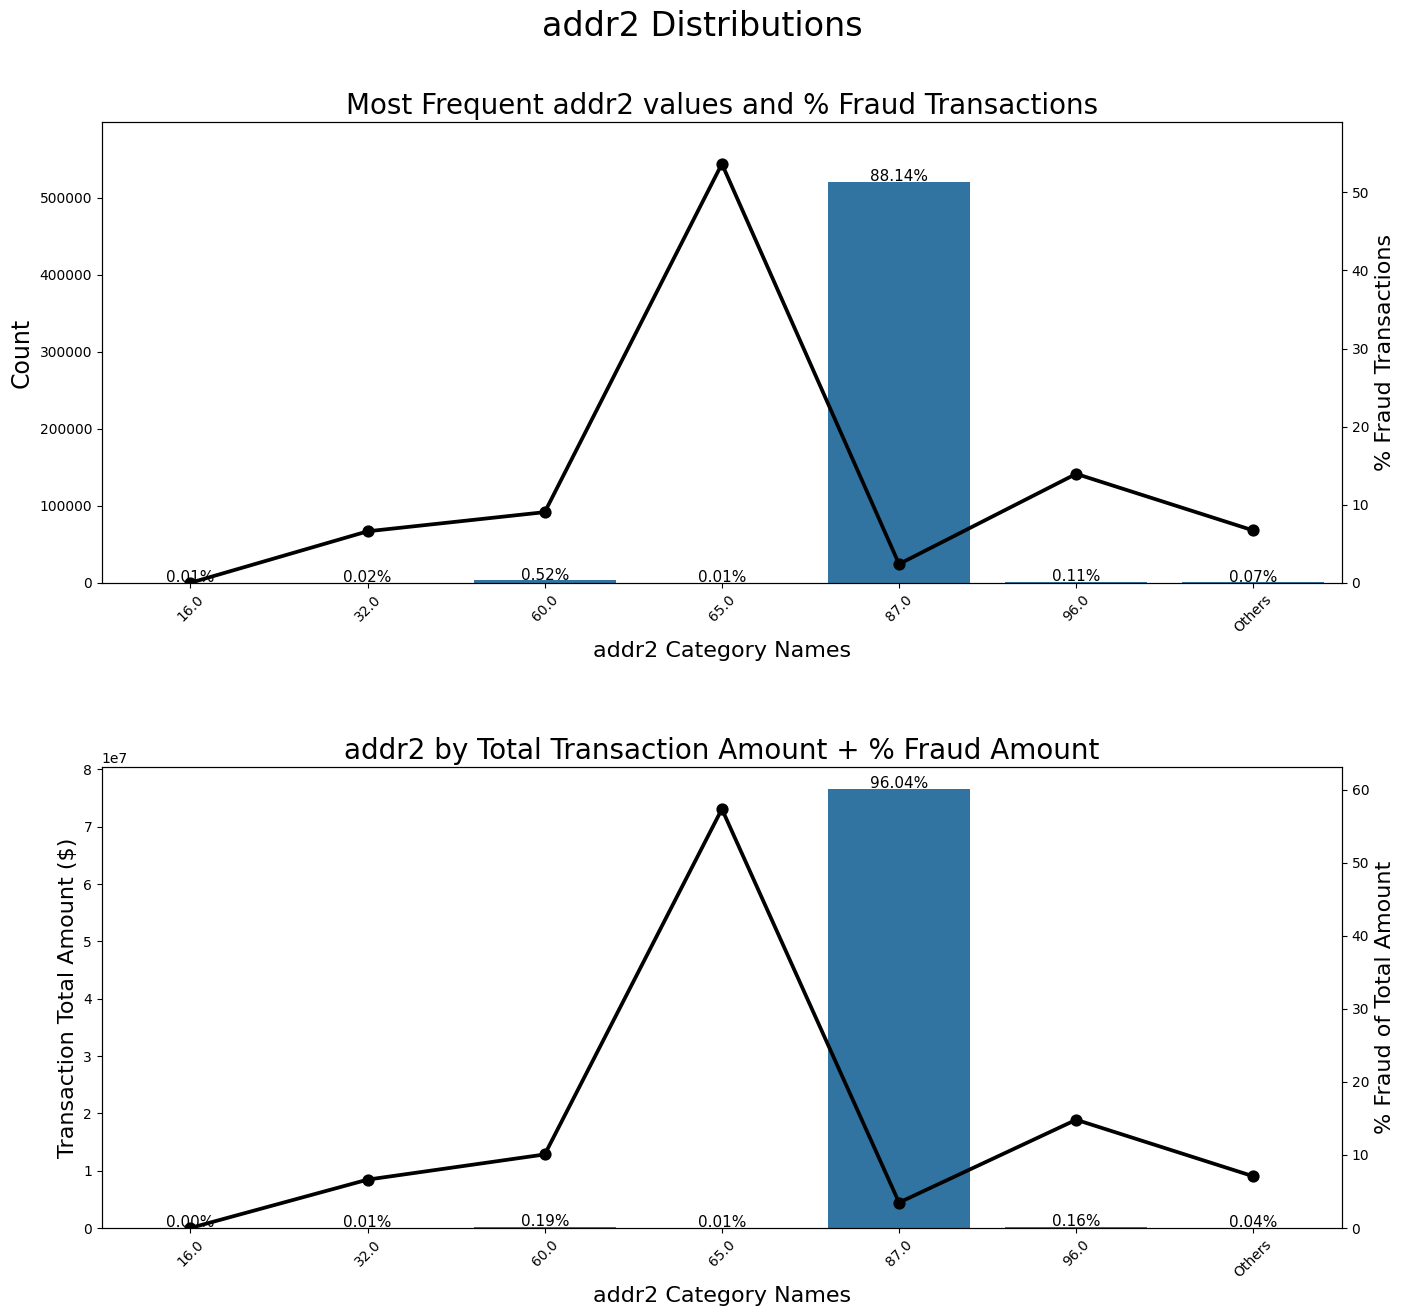

In [110]:
# Addr 2
ploting_cnt_amt(df_trans, 'addr2')

P emaildomain Distributions
We group all e-mail domains by the respective enterprises.Also, We will set as "Others" all values with less than 500 entries.
Fraudsters often use certain email providers or disposable domains.

We group email domains by provider to detect:

Fraud-heavy providers
Differences between purchaser and recipient emails

In [111]:
df_trans.loc[df_trans['P_emaildomain'].isin(['gmail.com', 'gmail']),'P_emaildomain'] = 'Google'

df_trans.loc[df_trans['P_emaildomain'].isin(['yahoo.com', 'yahoo.com.mx',  'yahoo.co.uk',
                                         'yahoo.co.jp', 'yahoo.de', 'yahoo.fr',
                                         'yahoo.es']), 'P_emaildomain'] = 'Yahoo Mail'
df_trans.loc[df_trans['P_emaildomain'].isin(['hotmail.com','outlook.com','msn.com', 'live.com.mx',
                                         'hotmail.es','hotmail.co.uk', 'hotmail.de',
                                         'outlook.es', 'live.com', 'live.fr',
                                         'hotmail.fr']), 'P_emaildomain'] = 'Microsoft'
df_trans.loc[df_trans.P_emaildomain.isin(df_trans.P_emaildomain\
                                         .value_counts()[df_trans.P_emaildomain.value_counts() <= 500 ]\
                                         .index), 'P_emaildomain'] = "Others"
df_trans.P_emaildomain.fillna("NoInf", inplace=True)

Ploting P-Email Domain

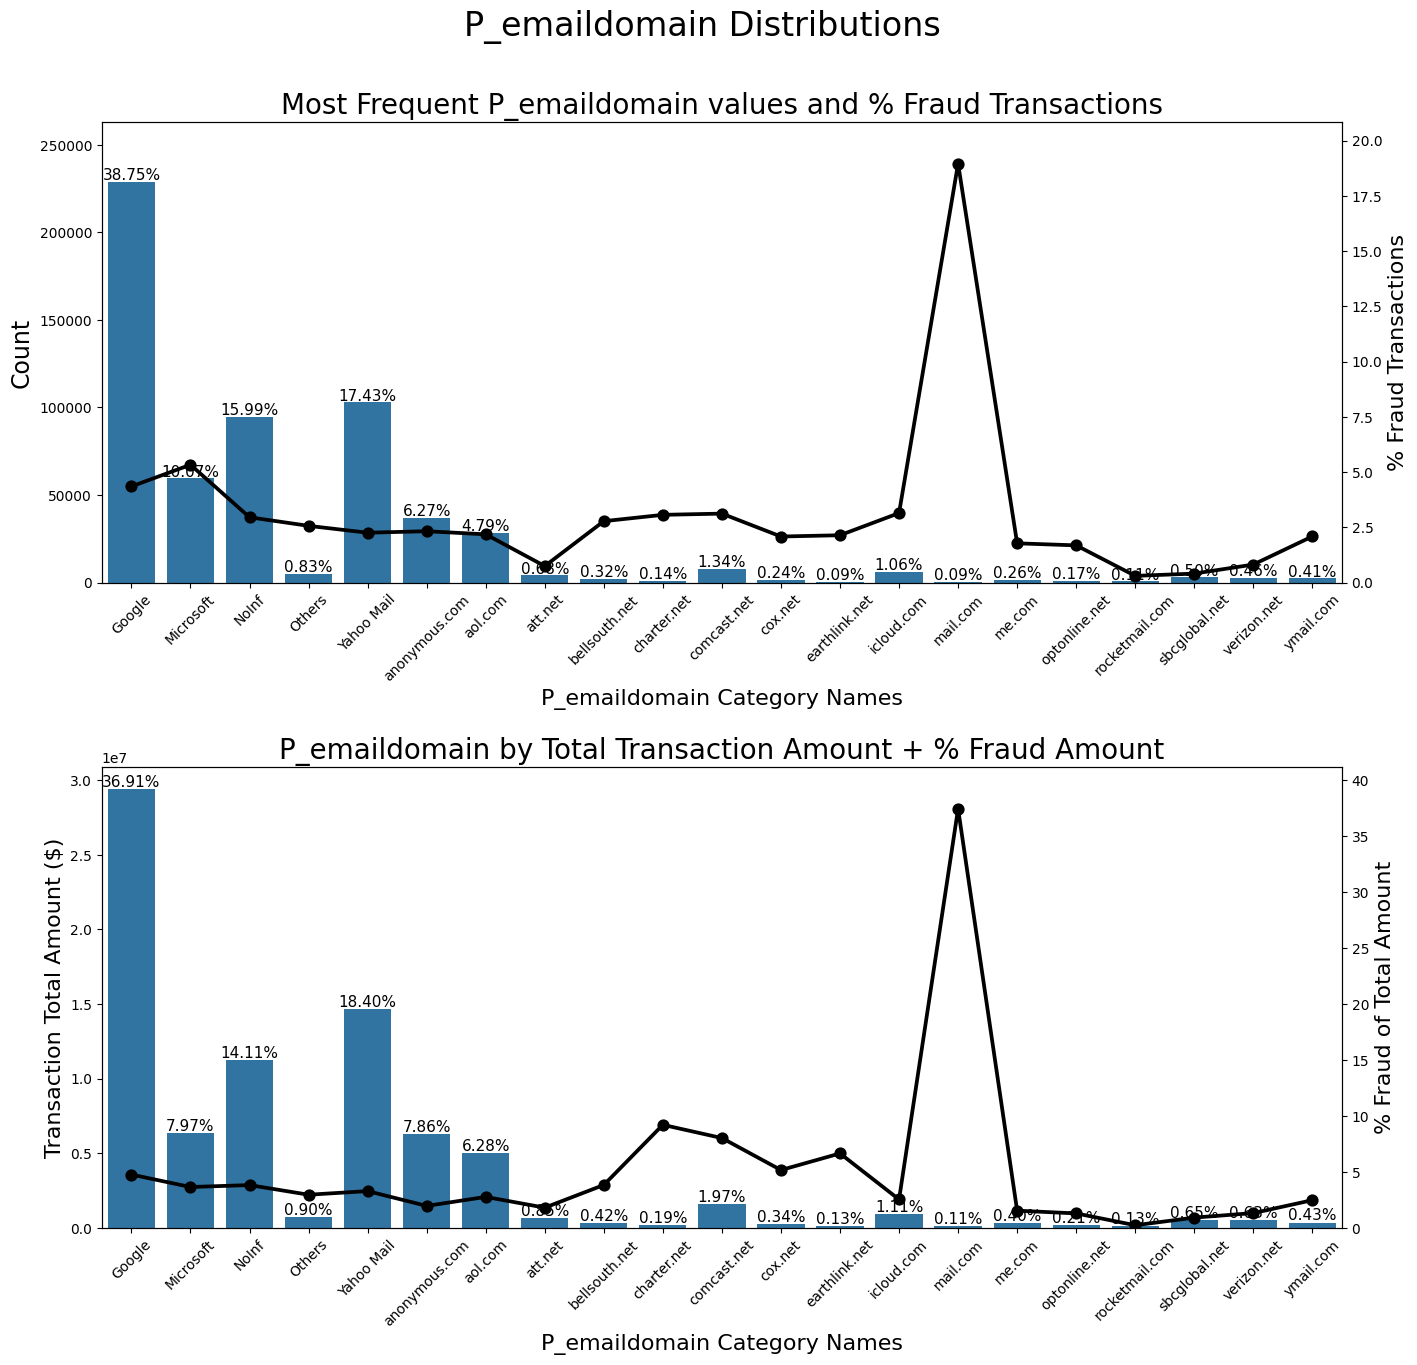

In [112]:
ploting_cnt_amt(df_trans, 'P_emaildomain')

R-Email Domain plot distribution

I will group all e-mail domains by the respective enterprises.
I will set as "Others" all values with less than 300 entries.

In [113]:
df_trans.loc[df_trans['R_emaildomain'].isin(['gmail.com', 'gmail']),'R_emaildomain'] = 'Google'

df_trans.loc[df_trans['R_emaildomain'].isin(['yahoo.com', 'yahoo.com.mx',  'yahoo.co.uk',
                                             'yahoo.co.jp', 'yahoo.de', 'yahoo.fr',
                                             'yahoo.es']), 'R_emaildomain'] = 'Yahoo Mail'
df_trans.loc[df_trans['R_emaildomain'].isin(['hotmail.com','outlook.com','msn.com', 'live.com.mx',
                                             'hotmail.es','hotmail.co.uk', 'hotmail.de',
                                             'outlook.es', 'live.com', 'live.fr',
                                             'hotmail.fr']), 'R_emaildomain'] = 'Microsoft'
df_trans.loc[df_trans.R_emaildomain.isin(df_trans.R_emaildomain\
                                         .value_counts()[df_trans.R_emaildomain.value_counts() <= 300 ]\
                                         .index), 'R_emaildomain'] = "Others"
df_trans.R_emaildomain.fillna("NoInf", inplace=True)

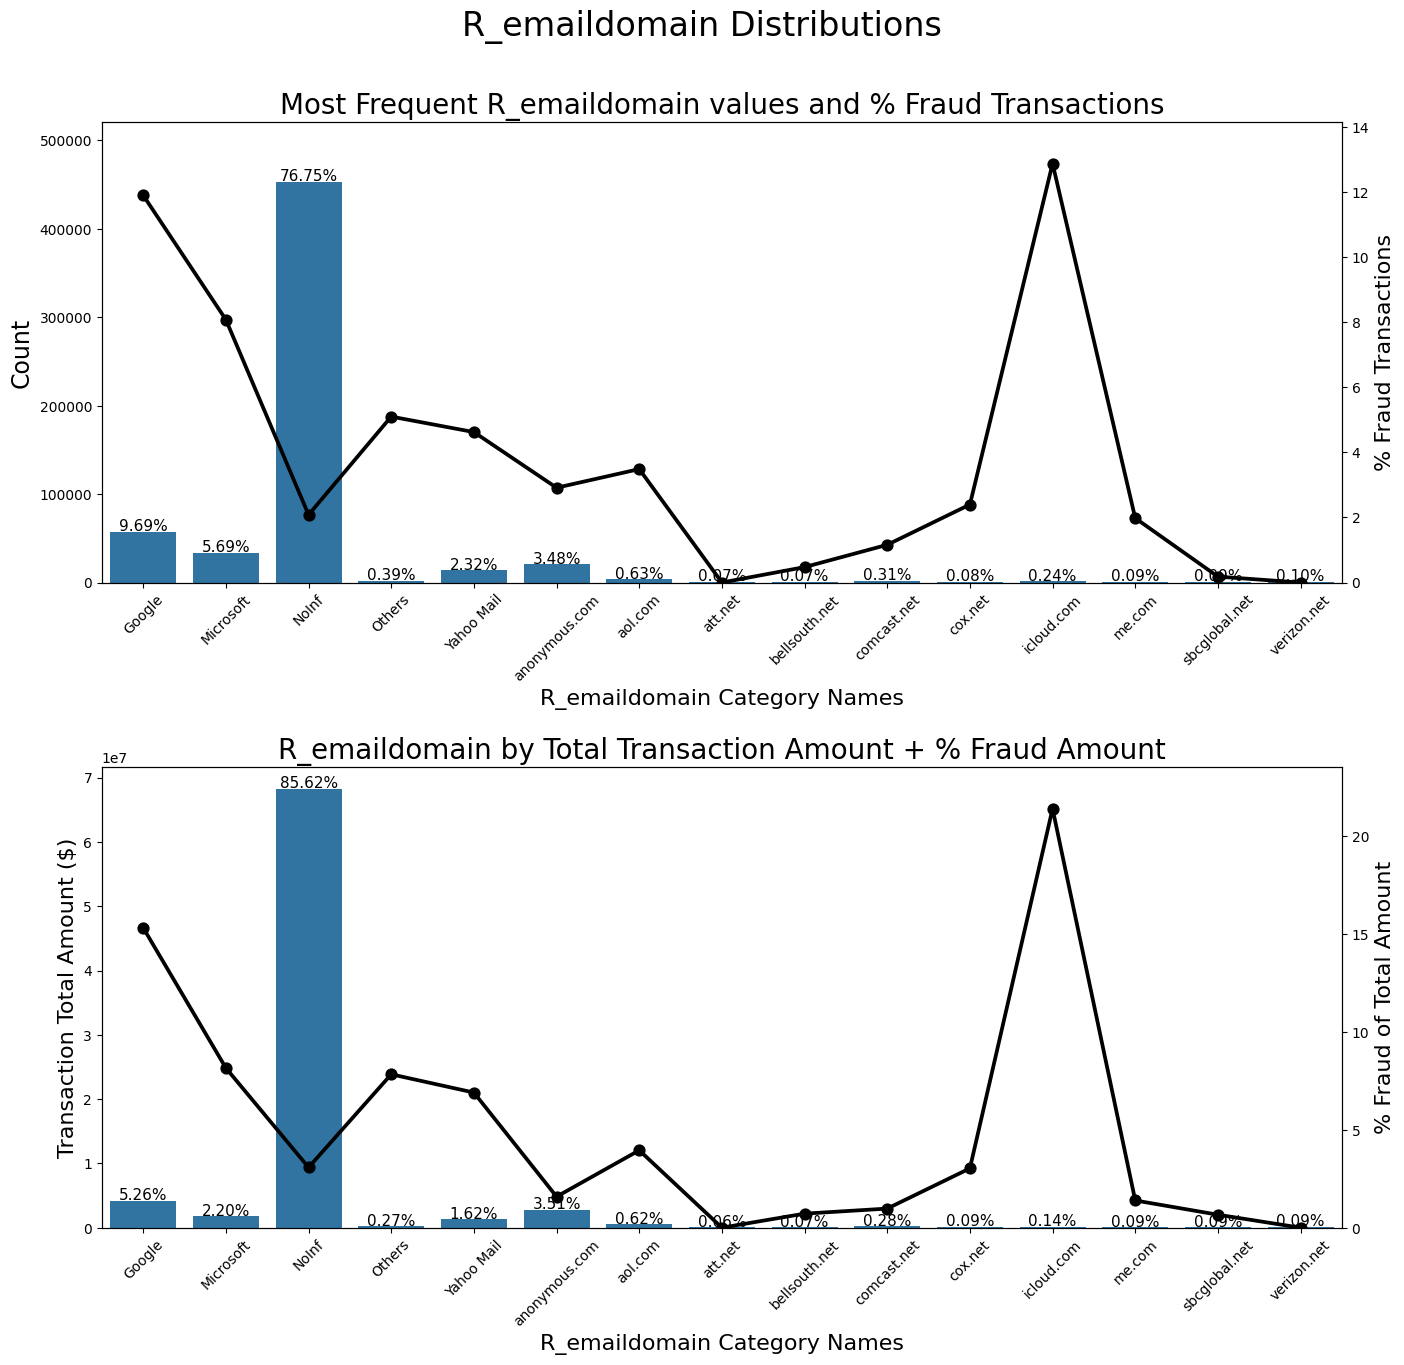

In [114]:
ploting_cnt_amt(df_trans, 'R_emaildomain')


C1-C14 features

In [115]:
resumetable(df_trans[['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8',
                      'C9', 'C10', 'C11', 'C12', 'C13', 'C14']])

Dataset Shape: (590540, 14)


,Name,dtypes,Missing,Uniques,First Value,Second Value,Third Value,Entropy
0,C1,float16,0,1495,1.0,1.0,1.0,2.72
1,C2,float16,0,1167,1.0,1.0,1.0,2.75
2,C3,float16,0,27,0.0,0.0,0.0,0.04
3,C4,float16,0,1223,0.0,0.0,0.0,1.12
4,C5,float16,0,319,0.0,0.0,0.0,2.06
5,C6,float16,0,1291,1.0,1.0,1.0,2.52
6,C7,float16,0,1069,0.0,0.0,0.0,0.71
7,C8,float16,0,1130,0.0,0.0,0.0,1.25
8,C9,float16,0,205,1.0,0.0,1.0,2.62
9,C10,float16,0,1122,0.0,0.0,0.0,1.23


In [116]:
df_trans[['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8',
                      'C9', 'C10', 'C11', 'C12', 'C13', 'C14']].describe()

,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14
count,590540.0,590540.0,590540.0,590540.0,590540.0,590540.0,590540.0,590540.0,590540.0,590540.0,590540.0,590540.0,590540.0,590540.0
mean,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0
50%,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,3.0,1.0
75%,3.0,3.0,0.0,0.0,1.0,2.0,0.0,0.0,2.0,0.0,2.0,0.0,12.0,2.0
max,4684.0,5692.0,26.0,2252.0,349.0,2252.0,2256.0,3332.0,210.0,3256.0,3188.0,3188.0,2918.0,1429.0


In [ ]:
df_trans[['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8',
                      'C9', 'C10', 'C11', 'C12', 'C13', 'C14']].describe()

In [ ]:
ploting_cnt_amt(df_trans, 'C1')

In [ ]:
df_trans.loc[df_trans.C2.isin(df_trans.C2\
                              .value_counts()[df_trans.C2.value_counts() <= 350 ]\
                              .index), 'C2'] = "Others"

In [ ]:
ploting_cnt_amt(df_trans, 'C2')

##### TimeDelta Feature
- Let's see if the frauds have some specific hour that has highest % of frauds
- Converting to Total Days, Weekdays and Hours.

We convert transaction timestamps into human-readable time features.

In [ ]:
import datetime

START_DATE = '2017-12-01'
startdate = datetime.datetime.strptime(START_DATE, "%Y-%m-%d")
df_trans["Date"] = df_trans['TransactionDT'].apply(lambda x: (startdate + datetime.timedelta(seconds=x)))

df_trans['_Weekdays'] = df_trans['Date'].dt.dayofweek
df_trans['_Hours'] = df_trans['Date'].dt.hour
df_trans['_Days'] = df_trans['Date'].dt.day

Features [id_12 to id_38]

In [ ]:
df_id[['id_12', 'id_13', 'id_14', 'id_15', 'id_16', 'id_17', 'id_18',
       'id_19', 'id_20', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25',
       'id_26', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_32',
       'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38']].describe(include='all')